# Parliamentary Inquiry Text Mining Report

**Author:** Juan Vargas T.  
**Email:** juan.vargastorres@student.uts.edu.au  
**Website:** [https://jsebastianv.com](https://jsebastianv.com)

---


## Table of Contents

Use the links below to jump to each section.

0. [Utilities](#utilities)
   - [0.0 Environment setup](#utilities)
   - [0.1 Imports and package setup](#utilities)
   - [0.2 Global constants and visual theme](#utilities)
   - [0.3 Data models and metadata parsing classes](#utilities)
   - [0.4 Corpus ingestion service class](#utilities)
   - [0.5 Text preprocessing class and helper functions](#utilities)
1. [Introduction](#introduction)
2. [Data Ingestion](#data-ingestion)
3. [Exploratory Data Analysis](#exploratory-data-analysis)
   - [3.1 Corpus overview visuals](#exploratory-data-analysis)
   - [3.2 Corpus composition by submitter type](#exploratory-data-analysis)
   - [3.3 Distribution of document word counts](#exploratory-data-analysis)
   - [3.4 Relationship between pages and word counts](#exploratory-data-analysis)
   - [3.5 Character counts by submitter type](#exploratory-data-analysis)
   - [3.6 Linguistic annotation sample (NER and POS)](#exploratory-data-analysis)
4. [Preprocessing](#pre-processing)
   - [4.1 Prepare cleaned tokens and lexical metrics](#pre-processing)
   - [4.2 Most common words](#pre-processing)
   - [4.3 Corpus snapshot statistics](#pre-processing)
   - [4.4 Length comparison by submitter type](#pre-processing)
   - [4.5 Frequency table preparation (unigrams, NPMI bigrams, and NPMI trigrams)](#pre-processing)
   - [4.6 Top unigram frequency chart](#pre-processing)
   - [4.7 Bigram phrase visuals (frequency chart and network graph)](#pre-processing)
   - [4.8 Top three-gram frequency chart (using NPMI phrase output)](#pre-processing)
   - [4.9 Initial preprocessing interpretation](#pre-processing)
   - [4.10 Word cloud of preprocessed corpus](#pre-processing)
5. [Advanced Methods (Topic Modeling and Clustering)](#topic-modeling)
   - [5.1 Topic modeling with LDA](#topic-modeling)
   - [5.2 Topic prevalence across submissions](#topic-modeling)
   - [5.3 Hierarchical clustering of submissions](#topic-modeling)
   - [5.4 K-means cluster selection](#topic-modeling)
   - [5.5 K-means cluster interpretation](#topic-modeling)
6. [Conclusion](#conclusion)
7. [References](#references)

---

<a id="utilities"></a>

## 0. Utilities

This section centralizes reusable setup so the rest of the notebook is clean and modular.

Utilities sub-sections are listed in the Table of Contents above.

### 0.0 Environment setup

Run this once per environment to install all required libraries from the project requirements file.

In [1]:
# 0.0 Install required libraries
%pip install -r requirements.txt

import sys
import subprocess

if sys.version_info < (3, 14):
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
else:
    print("spaCy model download skipped on Python 3.14+; NLTK fallback will be used for NER.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 2.4 MB/s  0:00:02m0:00:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 5.4 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn]4 [numba]
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 6.1 MB/s  0:00:02 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


### 0.1 Imports and package setup

Load required Python libraries and NLTK resources used throughout the notebook.

In [2]:
# 0.1 Imports and package setup

from pathlib import Path
import re
import string
import logging
import sys
import subprocess
from dataclasses import dataclass
from collections import Counter
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.cluster.hierarchy import dendrogram, linkage
from wordcloud import WordCloud

try:
    import fitz
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pymupdf"])
    import fitz

try:
    from gensim.corpora import Dictionary
    from gensim.models.coherencemodel import CoherenceModel
    from gensim.models.phrases import Phrases, Phraser
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gensim"])
    from gensim.corpora import Dictionary
    from gensim.models.coherencemodel import CoherenceModel
    from gensim.models.phrases import Phrases, Phraser

try:
    import networkx as nx
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "networkx"])
    import networkx as nx

try:
    import umap.umap_ as umap
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])
    import umap.umap_ as umap

import nltk
from nltk.corpus import stopwords, wordnet as wn
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import silhouette_score

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("maxent_ne_chunker_tab", quiet=True)
nltk.download("words", quiet=True)

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
LOGGER = logging.getLogger("nlp_report")


### 0.2 Global constants and visual theme

Define palette values, stopword settings, label mappings, and plotting defaults.

In [3]:
# 0.2 Global constants and visual theme

UTS_PALETTE = {
    "blue": "#0F4BEB",
    "red": "#FF2305",
    "black": "#000000",
    "dark_grey": "#323232",
    "mid_grey": "#B2B2B2",
    "light_grey": "#EBEBEB",
    "white": "#FFFFFF",
}

DOCS_DIR = Path("docs")
# DOMAIN_STOPWORDS contains words that are contextually frequent but not meaningful for semantic analysis
# in the parliamentary submissions corpus. These include words describing the process or context
# ("submission", "submissions", "inquiry", "committee", "electoral", "election", "federal", 
# "australian", "australia", "parliament") that do not add value for content-based text mining.
DOMAIN_STOPWORDS = {
    "submission", "submissions", "inquiry", "committee", "electoral",
    "election", "federal", "australian", "australia", "parliament"
}

# PUNCT_SET includes standard punctuation plus additional typographical marks and quotation variants
# that may occur in parliamentary submissions. This is to robustly detect and remove all forms of
# punctuation, including ellipses and different quote and dash styles, for thorough token cleaning.
PUNCT_SET = set(string.punctuation).union({
    "...", "''", "``", "’", "“", "”", "–", "—", ".", ","
})

SPACY_ENTITY_LABEL_DESCRIPTIONS = {
    "PERSON": "People, including fictional",
    "NORP": "Nationalities, Religious, or Political groups",
    "FAC": "Buildings, Airports, Highways, Bridges, etc.",
    "ORG": "Companies, Agencies, Institutions, etc.",
    "GPE": "Countries, Cities, States",
    "LOC": "Non-GPE locations, Mountain ranges, Bodies of water",
    "PRODUCT": "Objects, Vehicles, Foods, etc. (Not services)",
    "EVENT": "Named hurricanes, battles, wars, sports events, etc.",
    "WORK_OF_ART": "Titles of books, songs, etc.",
    "LAW": "Named documents made into laws",
    "LANGUAGE": "Any named language",
    "DATE": "Absolute or relative dates or periods",
    "TIME": "Times smaller than a day",
    "PERCENT": "Percentage",
    "MONEY": "Monetary values, including unit",
    "QUANTITY": "Measurements, as of weight or distance",
    "ORDINAL": "First, second, etc.",
    "CARDINAL": "Numerals that do not fall under another type",
}

ORG_NAME_INDICATORS = {
    "association", "assn", "institute", "foundation", "committee", "commission",
    "council", "union", "party", "group", "alliance", "network", "society",
    "organisation", "organization", "org", "company", "co", "corp", "corporation",
    "inc", "inc.", "ltd", "ltd.", "limited", "pty", "pty.", "trust", "church",
    "club", "board", "authority", "agency", "department", "office", "branch",
}
ORG_OVERRIDE_LABELS = {"NORP", "CARDINAL", "GPE"}

PENN_POS_TAG_MAP = {
    "CC": "Coordinating conjunction",
    "CD": "Cardinal number",
    "DT": "Determiner",
    "EX": "Existential there",
    "FW": "Foreign word",
    "IN": "Preposition/subordinating conjunction",
    "JJ": "Adjective",
    "JJR": "Adjective, comparative",
    "JJS": "Adjective, superlative",
    "LS": "List item marker",
    "MD": "Modal",
    "NN": "Noun, singular/common",
    "NNS": "Noun, plural",
    "NNP": "Proper noun, singular",
    "NNPS": "Proper noun, plural",
    "PDT": "Predeterminer",
    "POS": "Possessive ending",
    "PRP": "Personal pronoun",
    "PRP$": "Possessive pronoun",
    "RB": "Adverb",
    "RBR": "Adverb, comparative",
    "RBS": "Adverb, superlative",
    "RP": "Particle",
    "TO": "to",
    "UH": "Interjection",
    "VB": "Verb, base form",
    "VBD": "Verb, past tense",
    "VBG": "Verb, gerund/present participle",
    "VBN": "Verb, past participle",
    "VBP": "Verb, non-3rd person singular present",
    "VBZ": "Verb, 3rd person singular present",
    "WDT": "Wh-determiner",
    "WP": "Wh-pronoun",
    "WP$": "Possessive wh-pronoun",
    "WRB": "Wh-adverb",
}

sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = UTS_PALETTE["white"]
plt.rcParams["axes.facecolor"] = UTS_PALETTE["white"]
plt.rcParams["axes.edgecolor"] = UTS_PALETTE["dark_grey"]
plt.rcParams["axes.labelcolor"] = UTS_PALETTE["dark_grey"]
plt.rcParams["text.color"] = UTS_PALETTE["dark_grey"]

NLP = None
try:
    import spacy
    NLP = spacy.load("en_core_web_sm")
    LOGGER.info("Spacy model successfuly loaded")

except Exception:
    LOGGER.warning("spaCy is unavailable in this Python environment; NLTK fallback will be used for NER.")

2026-03-09 15:51:33,410 | INFO | Spacy model successfuly loaded


### 0.3 Data models and metadata parsing classes

Define configuration/data classes and metadata parsing logic.

In [4]:
# 0.3 Data models and metadata parsing classes

@dataclass(frozen=True)
class CorpusConfig:
    """Configuration object for ingestion and basic corpus filtering."""
    docs_dir: Path
    min_word_count: int = 1

In [5]:
class MetadataParser:
    """Parses metadata and provides metadata-linked NER utilities."""

    @staticmethod
    def infer_submitter_type(name: str, nlp_model=None) -> str:
        """Infer submitter category from submitter name using spaCy NER labels."""
        lowered = name.lower()
        if "withheld" in lowered or "name withheld" in lowered or "withhold" in lowered:
            return "Withheld"

        model = nlp_model if nlp_model is not None else NLP
        if model is None:
            return "Unknown"

        doc = model(name)
        labels = [ent.label_ for ent in doc.ents if ent.label_]
        unique_labels = list(dict.fromkeys(labels))
        filtered_labels = [label for label in unique_labels if label != "DATE"]
        LOGGER.info(
            "spaCy NER labels for '%s': all=%s | filtered=%s",
            name,
            set(unique_labels),
            set(filtered_labels),
        )

        if not filtered_labels:
            # Fallback heuristic: infer organisation when common org tokens appear.
            if any(indicator in lowered for indicator in ORG_NAME_INDICATORS):
                return SPACY_ENTITY_LABEL_DESCRIPTIONS["ORG"]
            return "Unknown"

        # Keep a single label with priority: ORG > PERSON > first remaining.
        if "ORG" in filtered_labels:
            selected_label = "ORG"
        elif "PERSON" in filtered_labels:
            selected_label = "PERSON"
        else:
            selected_label = filtered_labels[0]

        if selected_label in ORG_OVERRIDE_LABELS:
            selected_label = "ORG"

        return SPACY_ENTITY_LABEL_DESCRIPTIONS.get(selected_label, selected_label)

    @staticmethod
    def parse_filename(file_name: str) -> tuple[str, str, str]:
        """Parse file name into submission id, submitter name, and submitter type."""
        base = file_name.replace(".pdf", "")
        id_match = re.match(r"^(SupSub\d+\.\d+|Sub\d+(?:\sAtt\d+)?)", base)
        submission_id = id_match.group(1) if id_match else "Unknown"

        parts = base.split(" - ", 1)
        submitter = parts[1].strip() if len(parts) > 1 else "Unknown"
        submitter_type = MetadataParser.infer_submitter_type(submitter)
        return submission_id, submitter, submitter_type

    @staticmethod
    def extract_named_entities(text_series: pd.Series, nlp_model=None, max_docs: int | None = 120) -> pd.DataFrame:
        """Extract named entities using batched spaCy processing or NLTK fallback."""
        records = []
        iterable = text_series.head(max_docs) if max_docs is not None else text_series

        if nlp_model is not None:
            texts = iterable.fillna("").astype(str).tolist()
            LOGGER.info("NER extraction started with spaCy batching (max_docs=%s)", max_docs)

            try:
                doc_stream = nlp_model.pipe(texts, batch_size=20, n_process=-1)
                for doc_id, doc in enumerate(doc_stream):
                    for ent in doc.ents:
                        if ent.text.strip():
                            records.append(
                                {
                                    "doc_id": doc_id,
                                    "entity": ent.text.strip(),
                                    "label": ent.label_,
                                }
                            )
            except Exception as exc:
                LOGGER.warning(
                    "Parallel spaCy NER failed (%s); retrying with single-process batching.",
                    exc,
                )
                for doc_id, doc in enumerate(nlp_model.pipe(texts, batch_size=20)):
                    for ent in doc.ents:
                        if ent.text.strip():
                            records.append(
                                {
                                    "doc_id": doc_id,
                                    "entity": ent.text.strip(),
                                    "label": ent.label_,
                                }
                            )

            LOGGER.info("NER extraction finished with spaCy: %d entities", len(records))
            return pd.DataFrame(records)

        LOGGER.info("spaCy unavailable; using NLTK fallback for NER (max_docs=%s)", max_docs)
        for doc_id, text in enumerate(iterable):
            tokens = word_tokenize(str(text))
            if not tokens:
                continue

            tagged = pos_tag(tokens)
            chunks = ne_chunk(tagged, binary=False)

            for chunk in chunks:
                if hasattr(chunk, "label"):
                    entity_text = " ".join(token for token, _ in chunk.leaves()).strip()
                    if entity_text:
                        records.append(
                            {
                                "doc_id": doc_id,
                                "entity": entity_text,
                                "label": chunk.label(),
                            }
                        )

        return pd.DataFrame(records)

### 0.4 Corpus ingestion service class

Define the service that reads PDFs and builds ingestion records.

In [6]:
# 0.4 Corpus ingestion service class

class CorpusIngestionService:
    """Single-responsibility service for PDF extraction and corpus construction."""

    def __init__(self, config: CorpusConfig):
        """Initialize service with runtime corpus configuration."""
        self.config = config

    def extract_pdf_text(self, pdf_path: Path) -> tuple[str, int, bool]:
        """Extract text from a PDF and return text, page count, and extraction status."""
        text_parts = []
        page_count = 0
        extraction_ok = True

        try:
            with fitz.open(str(pdf_path)) as doc:
                page_count = len(doc)
                for page in doc:
                    text_parts.append(page.get_text("text") or "")
        except Exception as exc:
            extraction_ok = False
            LOGGER.warning("Failed to extract PDF: %s | error=%s", pdf_path.name, exc)

        raw_text = "\n".join(text_parts).strip()
        return raw_text, page_count, extraction_ok

    def read_corpus(self) -> pd.DataFrame:
        """Read all submission PDFs and build a filtered corpus dataframe."""
        pdf_paths = sorted(self.config.docs_dir.glob("*.pdf"))
        if not pdf_paths:
            raise FileNotFoundError("No PDFs found in docs/. Confirm dataset path before continuing.")

        LOGGER.info("Starting corpus ingestion from %s (%d files)", self.config.docs_dir, len(pdf_paths))

        records = []
        for pdf_path in pdf_paths:
            submission_id, submitter, submitter_type = MetadataParser.parse_filename(pdf_path.name)
            raw_text, page_count, extraction_ok = self.extract_pdf_text(pdf_path)

            records.append(
                {
                    "file_name": pdf_path.name,
                    "submission_id": submission_id,
                    "submitter": submitter,
                    "submitter_type": submitter_type,
                    "n_pages": page_count,
                    "extraction_ok": extraction_ok,
                    "raw_text": raw_text,
                }
            )

        corpus_df = pd.DataFrame(records)
        corpus_df["raw_text"] = corpus_df["raw_text"].fillna("")
        corpus_df["char_count"] = corpus_df["raw_text"].str.len()
        corpus_df["word_count_raw"] = corpus_df["raw_text"].str.split().str.len()

        filtered_df = corpus_df[corpus_df["word_count_raw"] >= self.config.min_word_count].reset_index(drop=True)
        LOGGER.info("Corpus ingestion complete: %d usable documents", len(filtered_df))
        return filtered_df

### 0.5 Text preprocessing class and helper functions

Define preprocessing utilities, chart helpers, and reusable analysis functions.

In [7]:
class TextPreprocessor:
    """Encapsulates token cleaning, phrase detection, and later lemmatization rules."""

    def __init__(self, domain_stopwords: set[str], punct_set: set[str]):
        """Build stopword, punctuation, and lemmatization resources."""
        base_stopwords = set(stopwords.words("english"))
        self.stop_words = base_stopwords.union(domain_stopwords)
        self.punct_set = punct_set
        self.lemmatizer = WordNetLemmatizer()

    @staticmethod
    def map_pos_tag(tag: str) -> str:
        """Map Penn Treebank tags to the WordNet tags used by the lemmatizer."""
        if tag.startswith("J"):
            return wn.ADJ
        if tag.startswith("V"):
            return wn.VERB
        if tag.startswith("R"):
            return wn.ADV
        return wn.NOUN

    @staticmethod
    def merge_entities(text: str, nlp_model=None):
        """Merge named entities so multiword mentions survive downstream tokenization."""
        model = nlp_model if nlp_model is not None else NLP
        if model is None:
            return None

        doc = model(str(text))
        if doc.ents:
            with doc.retokenize() as retokenizer:
                for ent in doc.ents:
                    retokenizer.merge(ent)
        return doc

    @staticmethod
    def normalize_token(token_text: str) -> str:
        """Normalize one token while preserving merged entity phrases with underscores."""
        normalized = re.sub(r"[^a-z_\s]", "", token_text.lower()).strip()
        return re.sub(r"\s+", "_", normalized).strip("_")

    def clean_tokens(self, text: str) -> list[str]:
        """Convert raw text into normalized tokens using entity-aware POS filtering."""
        if NLP is not None:
            doc = self.merge_entities(text)
            cleaned_tokens = []

            for token in doc:
                normalized = self.normalize_token(token.text)
                if not normalized:
                    continue

                is_named_entity = bool(token.ent_type_)
                if not is_named_entity and token.pos_ not in {"NOUN", "PROPN", "ADJ", "VERB"}:
                    continue
                if normalized in self.stop_words or normalized in self.punct_set:
                    continue

                cleaned_tokens.append(normalized)

            return cleaned_tokens

        tokens = word_tokenize(text.lower())
        tagged_tokens = pos_tag(tokens)
        return [
            token for token, tag in tagged_tokens
            if token.isalpha()
            and token not in self.stop_words
            and token not in self.punct_set
            and tag.startswith(("NN", "JJ", "VB"))
        ]

    @staticmethod
    def fit_pmi_bigram_model(token_sequences: Iterable[list[str]], min_count: int = 3, threshold: float = 0.6) -> Phraser:
        """Fit an NPMI-scored bigram phrase model on cleaned token sequences."""
        phrases = Phrases(
            token_sequences,
            min_count=min_count,
            threshold=threshold,
            scoring="npmi",
        )
        return Phraser(phrases)

    @staticmethod
    def fit_pmi_trigram_model(token_sequences: Iterable[list[str]], min_count: int = 3, threshold: float = 0.6) -> Phraser:
        """Fit an NPMI-scored trigram phrase model on bigram-transformed token sequences."""
        phrases = Phrases(
            token_sequences,
            min_count=min_count,
            threshold=threshold,
            scoring="npmi",
        )
        return Phraser(phrases)

    @staticmethod
    def apply_phrase_model(tokens: list[str], phrase_model: Phraser) -> list[str]:
        """Apply a trained phrase model to one token list."""
        if not tokens:
            return []
        return list(phrase_model[tokens])

    def lemmatize_tokens(self, tokens: list[str]) -> list[str]:
        """Lemmatize an already cleaned or phrase-detected token list after collocation analysis."""
        if not tokens:
            return []

        tagged_tokens = pos_tag(tokens)
        return [
            self.lemmatizer.lemmatize(token, self.map_pos_tag(tag))
            for token, tag in tagged_tokens
        ]


In [8]:
class TextAnalytics:
    """Collect reusable analytics helpers so notebook methods stay class-scoped."""

    @staticmethod
    def compute_ngram_counts(token_sequences: Iterable[list[str]], n: int = 2) -> Counter:
        """Compute n-gram frequencies from tokenized documents."""
        return Counter(gram for tokens in token_sequences for gram in ngrams(tokens, n))

    @staticmethod
    def extract_top_terms_per_topic(model: LatentDirichletAllocation, feature_names: np.ndarray, top_n: int = 10) -> pd.DataFrame:
        """Return a dataframe containing top terms for each topic in an LDA model."""
        topic_rows = []
        for topic_idx, topic_weights in enumerate(model.components_):
            top_indices = topic_weights.argsort()[::-1][:top_n]
            topic_rows.append(
                {
                    "topic": f"Topic {topic_idx + 1}",
                    "top_terms": ", ".join(feature_names[top_indices]),
                }
            )
        return pd.DataFrame(topic_rows)

    @staticmethod
    def extract_top_terms_per_cluster(matrix, labels: np.ndarray, feature_names: np.ndarray, top_n: int = 10,
                                      cluster_prefix: str = "Cluster") -> pd.DataFrame:
        """Return a dataframe containing top weighted terms for each document cluster."""
        matrix_dense = matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)
        labels_array = np.asarray(labels)
        cluster_rows = []

        for cluster_id in sorted(np.unique(labels_array)):
            cluster_matrix = matrix_dense[labels_array == cluster_id]
            if cluster_matrix.size == 0:
                continue

            mean_weights = cluster_matrix.mean(axis=0)
            top_indices = np.argsort(mean_weights)[::-1][:top_n]
            cluster_rows.append(
                {
                    "cluster": f"{cluster_prefix} {int(cluster_id) + 1}",
                    "top_terms": ", ".join(feature_names[top_indices]),
                }
            )
        return pd.DataFrame(cluster_rows)

    @staticmethod
    def get_coherence_score(
        lemmatized_docs: list[list[str]],
        lda_model: LatentDirichletAllocation,
        feature_names: np.ndarray,
        top_n: int = 10,
    ) -> float:
        """Score an sklearn LDA model with Gensim c_v coherence."""
        words_per_topic = []
        for topic_weights in lda_model.components_:
            top_indices = topic_weights.argsort()[::-1][:top_n]
            words_per_topic.append([feature_names[idx] for idx in top_indices])

        dictionary = Dictionary(lemmatized_docs)
        if len(dictionary) == 0:
            return np.nan

        coherence_model = CoherenceModel(
            topics=words_per_topic,
            texts=lemmatized_docs,
            dictionary=dictionary,
            coherence="c_v",
        )
        return coherence_model.get_coherence()

    @staticmethod
    def extract_regex_counts(text_series: pd.Series, pattern: str) -> pd.Series:
        """Extract regex matches from text series and return sorted frequency counts."""
        matches = text_series.str.findall(pattern)
        flattened = [item for sublist in matches for item in sublist]
        return pd.Series(flattened).value_counts()


In [9]:
class Visuals:
    """Reusable plotting helper for consistent chart styling and labeling."""

    def __init__(self, palette: dict[str, str]):
        """Initialize chart helper with a shared color palette."""
        self.palette = palette

    def bar(self, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str, color: str | None = None,
            hue: str | None = None, palette=None, figsize: tuple[int, int] = (10, 6), ax=None,
            gradient_by_value: bool = True, alpha_min: float = 0.25, alpha_max: float = 0.95):
        """Draw a configurable vertical bar chart with optional value-based opacity gradient."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.barplot(data=data, x=x, y=y, color=color, hue=hue, palette=palette, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        # Apply a gradient where higher values are rendered with higher opacity.
        if gradient_by_value and ax.patches:
            bar_values = [max(patch.get_width(), patch.get_height()) for patch in ax.patches]
            min_val = min(bar_values)
            max_val = max(bar_values)

            for patch, value in zip(ax.patches, bar_values):
                if max_val == min_val:
                    alpha = (alpha_min + alpha_max) / 2
                else:
                    scale = (value - min_val) / (max_val - min_val)
                    alpha = alpha_min + (scale * (alpha_max - alpha_min))
                patch.set_alpha(alpha)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def hist(self, series: pd.Series, title: str, xlabel: str, ylabel: str, bins: int = 30,
             color: str | None = None, edgecolor: str | None = None, figsize: tuple[int, int] = (10, 6), ax=None):
        """Draw a configurable histogram from a series."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.histplot(series, bins=bins, color=color, edgecolor=edgecolor, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def box(self, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str,
            palette=None, figsize: tuple[int, int] = (10, 6), ax=None):
        """Draw a configurable boxplot from dataframe columns."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.boxplot(data=data, x=x, y=y, palette=palette, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def scatter(self, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str,
                hue: str | None = None, palette=None, alpha: float = 0.7,
                figsize: tuple[int, int] = (10, 6), ax=None):
        """Draw a configurable scatterplot from dataframe columns."""
        if ax is None:
            _, ax = plt.subplots(figsize=figsize)
            show_plot = True
        else:
            show_plot = False

        sns.scatterplot(data=data, x=x, y=y, hue=hue, palette=palette, alpha=alpha, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        if show_plot:
            plt.tight_layout()
            plt.show()

    def bigram_network(self, tokens: list[str], title: str, n: int = 50, figsize: tuple[int, int] = (16, 12)):
        """Draw a bigram network graph from existing phrase tokens using the shared palette."""
        bigram_freq = Counter(
            tuple(token.split("_"))
            for token in tokens
            if isinstance(token, str) and token.count("_") == 1
        )
        if not bigram_freq:
            print("No phrase-based bigrams available to draw.")
            return

        graph = nx.Graph()
        edge_weights = []
        for bigram, count in bigram_freq.most_common(n):
            graph.add_edge(bigram[0], bigram[1], weight=count)
            edge_weights.append(count)

        if not edge_weights:
            print("No bigrams available to draw.")
            return

        edge_weights_array = np.array(edge_weights, dtype=float)
        if edge_weights_array.max() == edge_weights_array.min():
            edge_widths = np.full_like(edge_weights_array, 3.0)
        else:
            edge_widths = 1 + (edge_weights_array - edge_weights_array.min()) * 5 / (
                edge_weights_array.max() - edge_weights_array.min()
            )

        edge_cmap = LinearSegmentedColormap.from_list(
            "uts_bigram_edges",
            [self.palette["light_grey"], self.palette["blue"]],
        )
        norm = Normalize(vmin=edge_weights_array.min(), vmax=edge_weights_array.max())
        edge_colors = edge_cmap(norm(edge_weights_array))

        fig, ax = plt.subplots(figsize=figsize)
        pos = nx.spring_layout(graph, k=0.5, iterations=50, seed=42)

        nx.draw_networkx_nodes(
            graph,
            pos,
            node_size=1000,
            node_color=self.palette["light_grey"],
            edgecolors=self.palette["dark_grey"],
            linewidths=1.0,
            ax=ax,
        )
        nx.draw_networkx_edges(
            graph,
            pos,
            width=edge_widths,
            edge_color=edge_colors,
            alpha=0.9,
            arrows=False,
            ax=ax,
        )
        nx.draw_networkx_labels(
            graph,
            pos,
            font_size=10,
            font_weight="bold",
            font_color=self.palette["dark_grey"],
            ax=ax,
        )

        ax.set_title(title, color=self.palette["dark_grey"])
        ax.axis("off")

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        sm = plt.cm.ScalarMappable(cmap=edge_cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, cax=cax)
        cbar.set_label("Edge Weight (Bigram Frequency)", color=self.palette["dark_grey"])
        cbar.ax.yaxis.set_tick_params(color=self.palette["dark_grey"])
        plt.setp(cbar.ax.get_yticklabels(), color=self.palette["dark_grey"])

        plt.tight_layout()
        plt.show()

    def wordcloud(self, text: str, title: str, width: int = 1200, height: int = 500, max_words: int = 150,
                  colormap: str = "Blues", background_color: str | None = None, figsize: tuple[int, int] = (14, 6)):
        """Draw a word cloud from input text with consistent notebook styling."""
        cloud = WordCloud(
            width=width,
            height=height,
            max_words=max_words,
            colormap=colormap,
            collocations=False,
            background_color=background_color or self.palette["white"],
        ).generate(text)

        plt.figure(figsize=figsize)
        plt.imshow(cloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(title, color=self.palette["dark_grey"])
        plt.tight_layout()
        plt.show()

<a id="introduction"></a>

## 1. Introduction

This report analyses public submissions to the Australian parliamentary inquiry into the conduct of the 2025 federal election. Parliamentary inquiries play an important role in democratic policy development by collecting evidence from individuals and organisations and translating that evidence into recommendations for parliament. Using Natural Language Processing (NLP), this project transforms a large PDF-based corpus of submissions into interpretable insights about dominant concerns, recurring themes, and language patterns in public perspectives.

The analysis aims to answer three core questions: (1) What topics and issues appear most frequently across submissions? (2) How do linguistic patterns vary across different submitter types or submission groups inferred from metadata? and (3) What evidence-based insights can be communicated clearly to non-technical audiences? To address these questions, the workflow combines text extraction, preprocessing, exploratory analysis, and method-driven modeling with visual interpretation and plain-language reporting.

**How to read this report.** The notebook is structured as a story that moves from simple to complex. First, the corpus is built from the raw PDFs. Next, the report describes the basic shape of the data through charts and summary tables. It then cleans the text so that the analysis focuses on meaningful language rather than formatting noise. Finally, it applies topic modeling and clustering to uncover broader patterns that are harder to see from frequency counts alone.

Throughout the notebook, each section explains both **what method is being used** and **what the result means**. This is important because NLP techniques such as tokenization, Named Entity Recognition (NER), TF-IDF weighting, topic modeling, and clustering can produce outputs that look technical unless they are tied back to the research question.

<a id="data-ingestion"></a>

## 2. Data Ingestion

### Section Focus

This section loads all PDF submissions from `docs/`, extracts document text, and builds a structured corpus table for downstream NLP analysis.

**Why this matters.** NLP methods do not work directly on PDF files. Before any frequency analysis, visualization, topic modeling, or clustering can happen, the documents must be converted into machine-readable text and organized into a structured table. In this notebook, that table is `corpus_df`, and it becomes the foundation for every later step.

**What this ingestion step delivers:**
- one row per submission document,
- metadata parsed from filenames (submission ID, submitter label, simple submitter type),
- extraction diagnostics (page count, extraction status),
- text-length features (character and word counts),
- a clean `corpus_df` dataframe used in all later analysis sections.

A small but important storytelling feature in this notebook is the use of **metadata**. The filename is not just a technical label: it contains clues about who submitted the document, which makes it possible to compare patterns across people, organisations, withheld-name submissions, and unknown cases later in the analysis.

In [10]:
# 2.0 Data ingestion execution: build corpus dataframe using configured services

config = CorpusConfig(docs_dir=DOCS_DIR, min_word_count=1)
ingestion_service = CorpusIngestionService(config)
preprocessor = TextPreprocessor(domain_stopwords=DOMAIN_STOPWORDS, punct_set=PUNCT_SET)
visuals = Visuals(UTS_PALETTE)

corpus_df = ingestion_service.read_corpus()

LOGGER.info("Documents discovered: %d", len(list(DOCS_DIR.glob('*.pdf'))))
LOGGER.info("Documents with extracted text: %d", len(corpus_df))
LOGGER.info("Submitter type counts:\n%s", corpus_df["submitter_type"].value_counts())

print(f"Documents discovered: {len(list(DOCS_DIR.glob('*.pdf')))}")
print(f"Documents with extracted text: {len(corpus_df)}")
print("\nSubmitter type counts:")
print(corpus_df["submitter_type"].value_counts())

corpus_df.head(5)

2026-03-09 15:51:33,475 | INFO | Starting corpus ingestion from docs (299 files)
2026-03-09 15:51:33,488 | INFO | spaCy NER labels for 'Bob McMullan': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:33,509 | INFO | spaCy NER labels for 'Dr Sheppard': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:33,529 | INFO | spaCy NER labels for 'Grattan Institute': all={'ORG'} | filtered={'ORG'}
2026-03-09 15:51:33,745 | INFO | spaCy NER labels for 'Australian Electoral Commission': all={'ORG'} | filtered={'ORG'}
2026-03-09 15:51:33,872 | INFO | spaCy NER labels for 'The Australia Institute': all={'ORG'} | filtered={'ORG'}
2026-03-09 15:51:33,993 | INFO | spaCy NER labels for 'Andrew Murray': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:34,004 | INFO | spaCy NER labels for 'Genevieve Grant': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:34,016 | INFO | spaCy NER labels for 'Richard Ure': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:34,027 | INFO | spaCy NER l

MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: FT_New_Memory_Face(BCDGEE+ArialMT): unknown file format



2026-03-09 15:51:38,818 | INFO | spaCy NER labels for 'Chris Lynch': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:38,831 | INFO | spaCy NER labels for 'A-Prof Vanessa Teague': all=set() | filtered=set()
2026-03-09 15:51:38,862 | INFO | spaCy NER labels for 'Thomas Chick': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:39,133 | INFO | spaCy NER labels for 'Democracy Matters': all=set() | filtered=set()
2026-03-09 15:51:39,174 | INFO | spaCy NER labels for 'Microsoft': all={'ORG'} | filtered={'ORG'}
2026-03-09 15:51:39,188 | INFO | spaCy NER labels for 'Rationalist Society of Australia': all={'ORG'} | filtered={'ORG'}
2026-03-09 15:51:39,221 | INFO | spaCy NER labels for 'Stephen Swift': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:39,232 | INFO | spaCy NER labels for 'Antony Green': all={'ORG'} | filtered={'ORG'}
2026-03-09 15:51:39,277 | INFO | spaCy NER labels for 'Kevin Bonham': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:39,313 | INFO | spaCy NER l

MuPDF error: syntax error: Failed to read JPX header



2026-03-09 15:51:39,901 | INFO | spaCy NER labels for 'Peter Rickards': all={'PERSON'} | filtered={'PERSON'}


...

2026-03-09 15:51:39,952 | INFO | spaCy NER labels for 'Geoffrey Gilbert': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:39,960 | INFO | spaCy NER labels for 'Rob Davies': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:39,970 | INFO | spaCy NER labels for 'Electoral Reform Society of SA': all={'ORG'} | filtered={'ORG'}
2026-03-09 15:51:39,994 | INFO | spaCy NER labels for 'Philip Lillingston': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:40,080 | INFO | spaCy NER labels for 'Dr Vered Schildkraut': all={'PERSON'} | filtered={'PERSON'}


MuPDF error: library error: zlib error: incorrect header check

MuPDF error: library error: FT_New_Memory_Face(AAAAAI+ArialMT): unknown file format



2026-03-09 15:51:40,092 | INFO | spaCy NER labels for 'Ray Tunstall': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:40,105 | INFO | spaCy NER labels for 'Ray Carter': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:40,116 | INFO | spaCy NER labels for 'Unknown': all=set() | filtered=set()
2026-03-09 15:51:40,126 | INFO | spaCy NER labels for 'Heather Reid et al': all={'PERSON'} | filtered={'PERSON'}
2026-03-09 15:51:40,140 | INFO | spaCy NER labels for 'Grattan Institute': all={'ORG'} | filtered={'ORG'}
2026-03-09 15:51:40,148 | INFO | spaCy NER labels for 'Australian Electoral Commission': all={'ORG'} | filtered={'ORG'}
2026-03-09 15:51:40,228 | INFO | spaCy NER labels for 'Australian Electoral Commission': all={'ORG'} | filtered={'ORG'}
2026-03-09 15:51:40,287 | INFO | spaCy NER labels for 'Australia Institute': all={'ORG'} | filtered={'ORG'}
2026-03-09 15:51:40,294 | INFO | spaCy NER labels for 'Australia Institute': all={'ORG'} | filtered={'ORG'}
2026-03-09 15:51:40,3

Documents discovered: 299
Documents with extracted text: 299

Submitter type counts:
submitter_type
People, including fictional                132
Withheld                                    99
Companies, Agencies, Institutions, etc.     53
Unknown                                     15
Name: count, dtype: int64


,file_name,submission_id,submitter,submitter_type,n_pages,extraction_ok,raw_text,char_count,word_count_raw
0,Sub001 - Bob McMullan.pdf,Sub001,Bob McMullan,"People, including fictional",2,True,Time to revisit territory representation \nInt...,4132,662
1,Sub002 - Dr Sheppard.pdf,Sub002,Dr Sheppard,"People, including fictional",4,True,Inquiry into the 2025 federal election\nSubmis...,4994,782
2,Sub003 - Grattan Institute.pdf,Sub003,Grattan Institute,"Companies, Agencies, Institutions, etc.",13,True,Submission to the Inquiry into the 2025 federa...,35871,4849
3,Sub004 - Australian Electoral Commission.pdf,Sub004,Australian Electoral Commission,"Companies, Agencies, Institutions, etc.",19,True,AEC SUBMISSION \nJoint Standing Committee on E...,68701,10131
4,Sub005 - The Australia Institute.pdf,Sub005,The Australia Institute,"Companies, Agencies, Institutions, etc.",55,True,Australian democracy in \n2025 \nSubmission to...,90198,12117


<a id="exploratory-data-analysis"></a>

## 3. Exploratory Data Analysis

### Section Focus

Following the Week 1 guidance (word counts, frequent terms, and cleaned-token patterns), this section establishes high-level corpus behavior before advanced modeling.

**What EDA means.** Exploratory Data Analysis (EDA) is the stage where we look at the dataset before applying more complex models. The goal is to understand what kind of corpus we have, how large the documents are, whether some groups dominate the data, and whether the text looks suitable for deeper NLP methods. Good EDA reduces the chance of misinterpreting later outputs.

**EDA outputs included below:**
- document-length distribution (histogram + grouped boxplot),
- cleaned-token vocabulary size and lexical diversity,
- top unigrams and bigrams after stopword and punctuation filtering,
- simple submitter-type comparison using filename-derived metadata,
- part-of-speech patterns and a sample Named Entity Recognition (NER) view,
- quick observations to motivate subsequent preprocessing and topic methods.


### 3.1 Corpus overview visuals

This subsection provides a high-level overview of the corpus dataframe before detailed token analysis. The statistics table and charts summarize corpus composition, document scale, and key structural relationships across submissions.

The main concept here is **descriptive statistics**: simple measures such as count, mean, median, minimum, maximum, and spread. These do not explain themes yet, but they tell us whether the corpus is balanced, skewed, or dominated by extreme cases.

In [11]:
# 3.1 Overview statistics table

overview_stats = corpus_df[["n_pages", "char_count", "word_count_raw"]].describe().T
display(overview_stats)

,count,mean,std,min,25%,50%,75%,max
n_pages,299.0,6.615385,12.334375,1.0,2.0,3.0,6.0,120.0
char_count,299.0,12828.986622,24063.722278,52.0,2087.0,5180.0,11686.0,216098.0
word_count_raw,299.0,1960.117057,3707.356393,8.0,343.0,815.0,1822.0,36258.0


**Interpretation.** The overview statistics establish the basic scale of the corpus: how long the submissions are in pages, characters, and words, and how much variation exists across documents. The wide ranges indicate that the notebook is not working with a uniform collection of standard-length texts.

**Why this matters.** This table sets expectations for the rest of the report. Large variation in document size means later results should be interpreted with distribution and document imbalance in mind, not just raw totals.

### 3.2 Corpus composition by submitter type

This chart shows how many submissions come from each inferred submitter category.

The key concept here is **metadata-based grouping**. Instead of looking only at document text, the notebook also groups submissions by information inferred from filenames and entity labels, which helps frame later comparisons across different kinds of submitters.

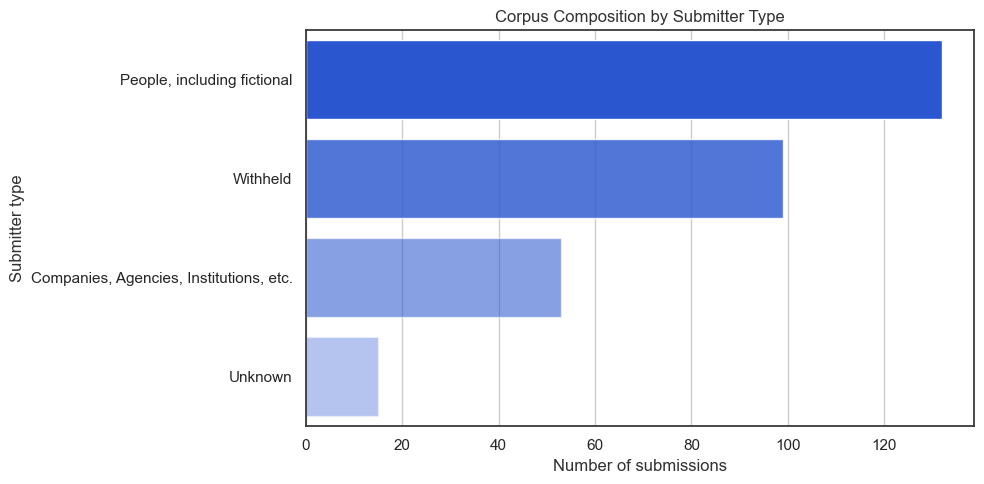

In [12]:
# 3.2 Visual: corpus composition by submitter type

submitter_counts = (
    corpus_df["submitter_type"]
    .value_counts()
    .rename_axis("submitter_type")
    .reset_index(name="count")
)

visuals.bar(
    data=submitter_counts,
    x="count",
    y="submitter_type",
    title="Corpus Composition by Submitter Type",
    xlabel="Number of submissions",
    ylabel="Submitter type",
    color=UTS_PALETTE["blue"],
    gradient_by_value=True,
    alpha_min=0.35,
    alpha_max=1.0,
    figsize=(10, 5),
)

**Interpretation.** The corpus is clearly not evenly distributed across submitter types, which means this is not a balanced dataset in the statistical sense. Individual submissions and withheld-name submissions make up a large share of the corpus, while organisation-style submissions are fewer in number.

**Why this matters.** Later charts may show some terms or themes appearing more often simply because one submitter group contributes more documents overall. In other words, frequency can reflect both **how strongly a group talks about something** and **how large that group is in the corpus**. This is why later comparisons should be read alongside both document counts and document lengths.

### 3.3 Distribution of document word counts

This histogram shows the spread of document sizes across submissions.

A **histogram** groups numeric values into bins and shows how often values fall into each range. Here, it helps answer a simple but important question: are most submissions roughly similar in length, or is the corpus dominated by a small number of very short or very long documents?

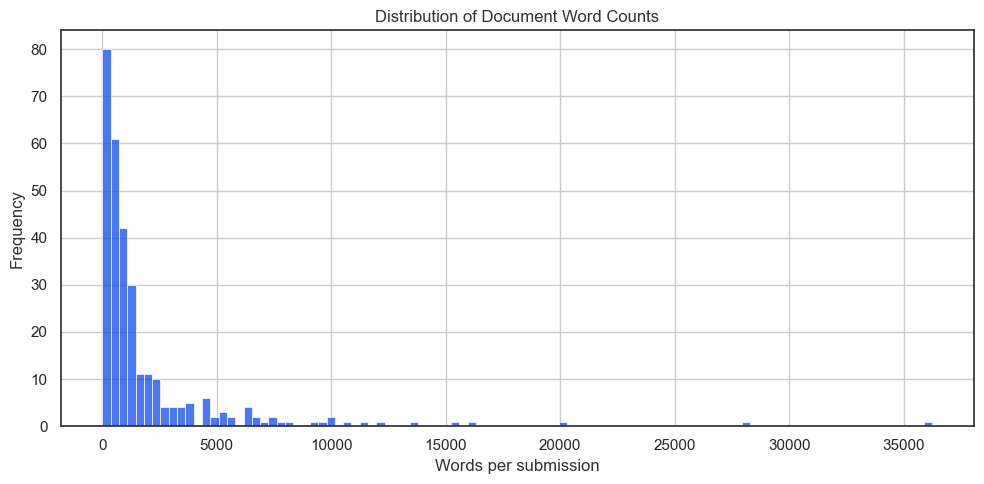

In [13]:
# 3.3 Visual: word-count distribution

visuals.hist(
    series=corpus_df["word_count_raw"],
    bins=100,
    color=UTS_PALETTE["blue"],
    edgecolor=UTS_PALETTE["white"],
    title="Distribution of Document Word Counts",
    xlabel="Words per submission",
    ylabel="Frequency",
    figsize=(10, 5),
)

**Interpretation.** Most submissions cluster in the shorter-to-middle length range, while a relatively small number extend far to the right of the chart as very large documents. That pattern is called **right skew**: the majority of values are lower, but a minority of very large cases stretch the distribution upward.

**Why this matters.** In a skewed corpus like this one, the **median** is often more informative than the mean because the mean can be pulled upward by unusually long submissions. This chart therefore suggests that the "typical" submission is much shorter than the few largest reports, which is useful context for later comparisons of vocabulary and topic prevalence.

In [14]:
# Find and show the entire row for the document with the largest word count
max_word_count_row = corpus_df.loc[corpus_df["word_count_raw"].idxmax()]
print("Document with the largest word count (entire row):")
display(max_word_count_row.to_frame().T)

# Find and show the entire row for the document with the smallest word count
min_word_count_row = corpus_df.loc[corpus_df["word_count_raw"].idxmin()]
print("Document with the smallest word count (entire row):")
display(min_word_count_row.to_frame().T)

Document with the largest word count (entire row):


,file_name,submission_id,submitter,submitter_type,n_pages,extraction_ok,raw_text,char_count,word_count_raw
140,Sub141 Att1 - Malcolm Mackerras.pdf,Sub141 Att1,Malcolm Mackerras,"People, including fictional",96,True,Inquiry into the 2025 federal election\nSubmis...,216098,36258


Document with the smallest word count (entire row):


,file_name,submission_id,submitter,submitter_type,n_pages,extraction_ok,raw_text,char_count,word_count_raw
14,Sub015 - Name withheld.pdf,Sub015,Name withheld,Withheld,1,True,Inquiry into the 2025 federal election\nSubmis...,52,8


**Interpretation.** Looking directly at the largest and smallest submissions makes the skewness in the histogram concrete. The longest document shows how much detail a single submission can contribute, while the shortest document shows that some cases may function more like brief statements than full reports.

**Why this matters.** Outlier inspection is a useful EDA habit because it turns abstract distribution summaries into real documents. It also warns us that a few especially long submissions could influence later corpus-wide counts more than their document count alone would suggest.

### 3.4 Relationship between pages and word counts

This scatter plot compares page counts with total words to show document scale relationships.

A **scatter plot** is useful when we want to see whether two numeric variables move together. Here, the question is whether the physical size of a submission in pages aligns with the amount of extracted text in words.

/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_84411/4266661574.py:87: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=data, x=x, y=y, hue=hue, palette=palette, alpha=alpha, ax=ax)


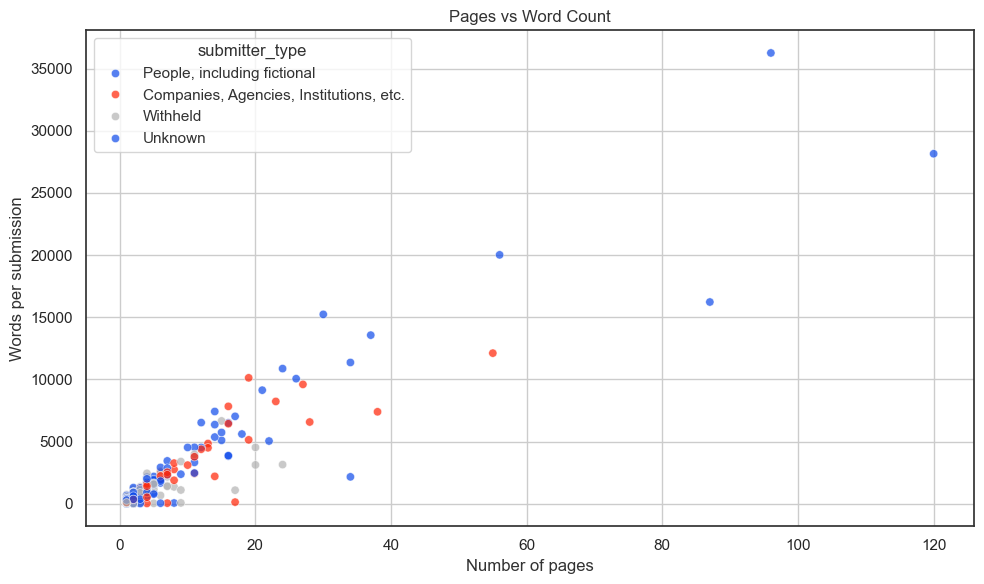

In [15]:
# 3.4 Visual: pages vs word counts

visuals.scatter(
    data=corpus_df,
    x="n_pages",
    y="word_count_raw",
    hue="submitter_type",
    palette=[UTS_PALETTE["blue"], UTS_PALETTE["red"], UTS_PALETTE["mid_grey"]],
    alpha=0.7,
    title="Pages vs Word Count",
    xlabel="Number of pages",
    ylabel="Words per submission",
    figsize=(10, 6),
)

**Interpretation.** The upward pattern in the scatter plot shows that longer documents in pages usually also contain more words, which is a reassuring sign that the PDF extraction step has captured usable text at the expected scale. At the same time, points with similar page counts still vary in word count, so not every page carries the same amount of text.

**Why this matters.** Page count is a helpful structural measure, but it is only an approximate proxy for textual richness. Formatting, tables, figures, headings, and spacing can all change how much language appears on a page. For later NLP work, this means the notebook should rely more heavily on text-based measures such as word counts and token frequencies than on page counts alone.

### 3.5 Character counts by submitter type

This boxplot compares character-count distributions by submitter category.

A **boxplot** summarizes the center, spread, and outliers of a distribution. It is especially useful when document lengths vary widely, because it shows the median and the typical range more clearly than a simple bar chart.

/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_84411/4266661574.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, palette=palette, ax=ax)
/var/folders/2f/4qv4v6_s6714t7lb2hc6jtqh0000gn/T/ipykernel_84411/4266661574.py:68: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=data, x=x, y=y, palette=palette, ax=ax)


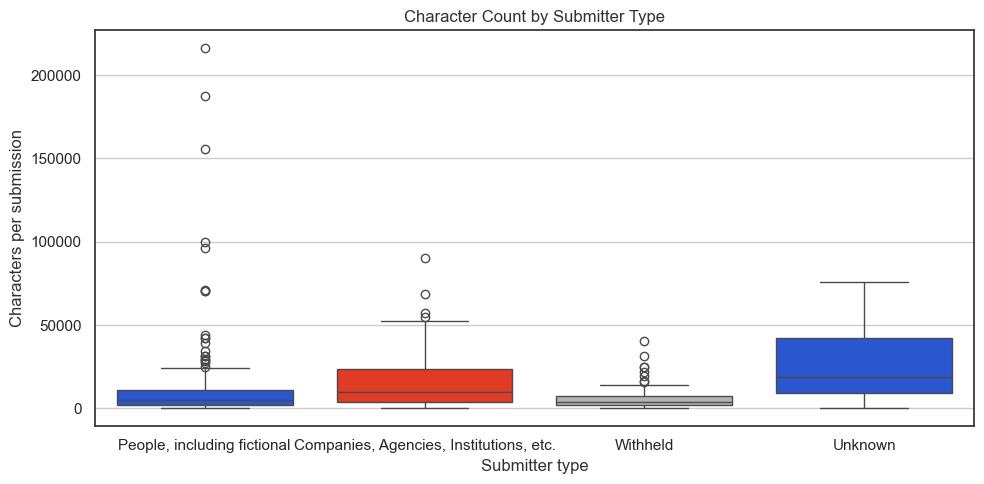

In [16]:
# 3.5 Visual: character count by submitter type

visuals.box(
    data=corpus_df,
    x="submitter_type",
    y="char_count",
    palette=[UTS_PALETTE["blue"], UTS_PALETTE["red"], UTS_PALETTE["mid_grey"]],
    title="Character Count by Submitter Type",
    xlabel="Submitter type",
    ylabel="Characters per submission",
    figsize=(10, 5),
)

**Interpretation.** Character counts vary substantially both within and across submitter types, which suggests that the corpus contains not just different kinds of writers but also different kinds of documents. Some submitters contribute short statements, while others contribute long, report-like texts.

**Why this matters.** Large documents naturally contribute more words, phrases, and entities, so they can dominate raw counts if the analysis is not interpreted carefully. This result supports the later use of medians, cleaned token counts, and document-level comparisons rather than relying only on corpus-wide totals.

### 3.6 Linguistic annotation sample (NER and POS)

This mini-section uses two common NLP annotation tasks to make the language in the corpus more interpretable before preprocessing and modeling.

**Named Entity Recognition (NER)** identifies spans of text corresponding to real-world entities such as people, organisations, places, dates, laws, or quantities. In a corpus like this one, NER is helpful because it shows which institutions, actors, and locations are explicitly named in the submissions.

**Part-of-Speech (POS) tagging** assigns a grammatical role to each token, such as noun, verb, adjective, or determiner. It does not tell us the topic directly, but it helps us understand what kind of language dominates the corpus and whether the text is likely to support later thematic analysis.

#### Named Entity Recognition (NER) sample view

The rendered sample below is included as a qualitative view rather than a full quantitative analysis. Its purpose is to make entity detection visible to the reader so the report does not treat NER as a hidden black box.

In [ ]:
# 3.7 NER sample rendering

if NLP is None:
    print("spaCy model unavailable, so inline NER rendering is skipped in this environment.")
else:
    ner_sample_sentences = []

    for text in corpus_df["raw_text"].fillna("").head(40):
        doc = NLP(str(text)[:6000])
        for sent in doc.sents:
            sent_text = re.sub(r"\s+", " ", sent.text).strip()
            if 50 <= len(sent_text) <= 220 and sent.ents:
                ner_sample_sentences.append(sent_text)
            if len(ner_sample_sentences) >= 10:
                break
        if len(ner_sample_sentences) >= 10:
            break

    if not ner_sample_sentences:
        print("No suitable sentences with named entities were found in the sampled documents.")
    else:
        ner_sample_docs = [NLP(sentence) for sentence in ner_sample_sentences]
        ner_sample_entities_df = MetadataParser.extract_named_entities(
            pd.Series(ner_sample_sentences),
            nlp_model=NLP,
            max_docs=len(ner_sample_sentences),
        )

        print("Sample sentences with detected named entities:")
        spacy.displacy.render(ner_sample_docs, style="ent", jupyter=True)

        print("Entity labels detected in the rendered sample:")
        display(
            ner_sample_entities_df["label"]
            .value_counts()
            .rename_axis("entity_label")
            .reset_index(name="count")
        )

**Interpretation.** The rendered sample makes NER more concrete: instead of only counting words, the model highlights who and what is being named in the text. In policy submissions, entity detection is useful because it can surface references to people, institutions, jurisdictions, dates, and other formally named items that structure the discussion.

**What to watch for.** NER is powerful but imperfect. Some entities will be missed, and some labels may be wrong or overly broad. The value of this section is therefore explanatory: it shows how named entities appear in the corpus and why they can support richer interpretation when combined with the frequency and clustering results.

#### Part-of-Speech (POS) analysis

The chart below tags words in a runtime-capped sample of submission text and summarizes the most frequent grammatical categories.

2026-03-09 15:51:45,204 | INFO | POS tagging complete: docs=120, tagged_tokens=207415


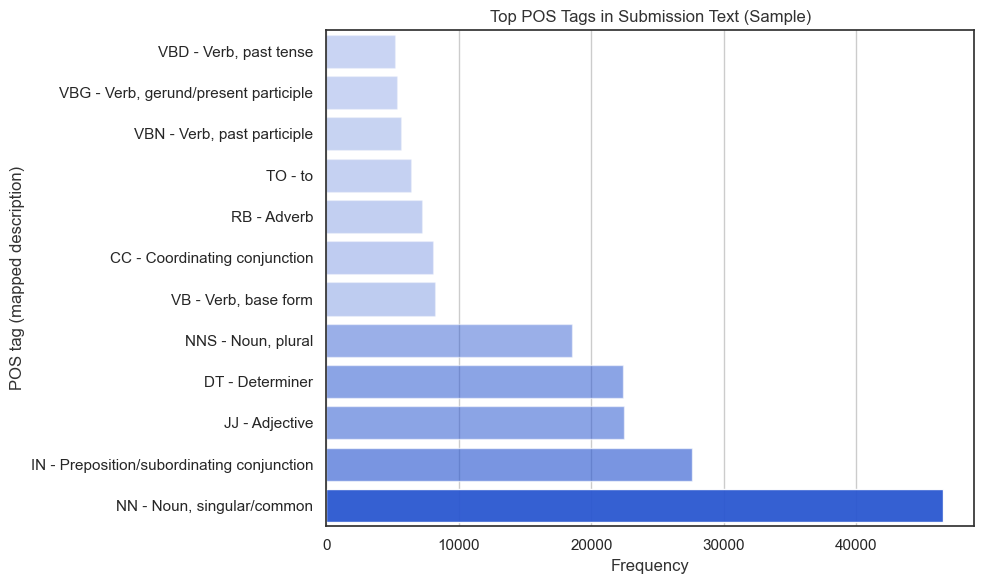

,pos_tag,pos_description,count
11,VBD,"Verb, past tense",5193
10,VBG,"Verb, gerund/present participle",5305
9,VBN,"Verb, past participle",5626
8,TO,to,6401
7,RB,Adverb,7208
6,CC,Coordinating conjunction,8055
5,VB,"Verb, base form",8228
4,NNS,"Noun, plural",18568
3,DT,Determiner,22413
2,JJ,Adjective,22473


In [17]:
# 3.6 POS analysis: top grammatical tags

pos_max_docs = 120
pos_tags = []

for text in corpus_df["raw_text"].head(pos_max_docs):
    tokens = [token.lower() for token in word_tokenize(str(text)) if token.isalpha()]
    if not tokens:
        continue
    pos_tags.extend(tag for _, tag in pos_tag(tokens))

pos_tag_counts = pd.Series(pos_tags, name="pos_tag").value_counts().reset_index()
pos_tag_counts.columns = ["pos_tag", "count"]
pos_tag_counts["pos_description"] = pos_tag_counts["pos_tag"].map(PENN_POS_TAG_MAP).fillna("Other/Unknown")
pos_tag_counts["pos_label"] = pos_tag_counts["pos_tag"] + " - " + pos_tag_counts["pos_description"]

top_pos_tags = pos_tag_counts.head(12).sort_values("count", ascending=True)

LOGGER.info(
    "POS tagging complete: docs=%d, tagged_tokens=%d",
    min(pos_max_docs, len(corpus_df)),
    len(pos_tags),
)

visuals.bar(
    data=top_pos_tags,
    x="count",
    y="pos_label",
    color=UTS_PALETTE["blue"],
    title="Top POS Tags in Submission Text (Sample)",
    xlabel="Frequency",
    ylabel="POS tag (mapped description)",
    figsize=(10, 6),
)

top_pos_tags[["pos_tag", "pos_description", "count"]]

**Interpretation.** Nouns, prepositions, determiners, and adjectives dominate the POS profile. That is typical of formal policy-style submissions because these documents spend a lot of time naming institutions, actors, procedures, and issues rather than using conversational or narrative language.

**Why this matters.** A noun-heavy corpus is usually a good sign for thematic text mining because nouns and noun phrases often carry the strongest topical meaning. The result also suggests that the submissions contain enough descriptive language to support later steps such as cleaned-term analysis, phrase detection, Named Entity Recognition, and topic modeling. The main limitation is that the POS chart is based on a runtime-capped sample rather than the full corpus.

<a id="pre-processing"></a>

## 4. Preprocessing

### 4.1 Prepare cleaned tokens and lexical metrics

This cell applies the preprocessing rules, creates cleaned token lists per document, and computes reusable corpus-level metrics such as cleaned word counts and lexical diversity.

**What preprocessing means.** Preprocessing is the stage where raw text is converted into an analysis-friendly form. In this notebook that includes tokenization, stopword removal, punctuation filtering, phrase detection, and lemmatization.

**Key concepts used here:**
- **Tokenization** splits text into individual units such as words.
- **Stopwords** are very common words that usually carry little topical meaning.
- **Lemmatization** reduces inflected words to a base form, so related variants like `votes`, `voted`, and `voting` can be compared more consistently.
- **Phrase detection** groups words that belong together, such as multiword concepts, so they are not broken apart during later analysis.
- **Lexical diversity** measures how varied a document's vocabulary is, usually by comparing unique words with total words.


In [18]:
# 4.1 Tokenization output and document-level lexical features

corpus_df["raw_tokens"] = corpus_df["raw_text"].apply(
    lambda text: [token.lower() for token in word_tokenize(str(text)) if token.isalpha()]
)
corpus_df["clean_tokens"] = corpus_df["raw_text"].apply(preprocessor.clean_tokens)

bigram_model = preprocessor.fit_pmi_bigram_model(corpus_df["clean_tokens"], min_count=3, threshold=0.6)
corpus_df["pmi_bigram_tokens"] = corpus_df["clean_tokens"].apply(
    lambda tokens: preprocessor.apply_phrase_model(tokens, bigram_model)
)

trigram_model = preprocessor.fit_pmi_trigram_model(corpus_df["pmi_bigram_tokens"], min_count=3, threshold=0.6)
corpus_df["pmi_trigram_tokens"] = corpus_df["pmi_bigram_tokens"].apply(
    lambda tokens: preprocessor.apply_phrase_model(tokens, trigram_model)
)

corpus_df["lemmatized_tokens"] = corpus_df["pmi_trigram_tokens"].apply(preprocessor.lemmatize_tokens)
corpus_df["preprocessed_text"] = corpus_df["lemmatized_tokens"].apply(" ".join)

corpus_df["clean_word_count"] = corpus_df["clean_tokens"].str.len()
corpus_df["lexical_diversity"] = corpus_df.apply(
    lambda r: (len(set(r["clean_tokens"])) / r["clean_word_count"]) if r["clean_word_count"] > 0 else np.nan,
    axis=1,
)

raw_all_tokens = [token for tokens in corpus_df["raw_tokens"] for token in tokens]
all_tokens = [token for tokens in corpus_df["clean_tokens"] for token in tokens]
pmi_bigram_vocab = {token for tokens in corpus_df["pmi_bigram_tokens"] for token in tokens}
pmi_trigram_vocab = {token for tokens in corpus_df["pmi_trigram_tokens"] for token in tokens}
lemmatized_vocab = {token for tokens in corpus_df["lemmatized_tokens"] for token in tokens}
vocab_size = len(set(all_tokens))
LOGGER.info(
    "Tokenization complete: raw_vocab_size=%d, clean_vocab_size=%d, bigram_vocab_size=%d, trigram_vocab_size=%d, lemmatized_vocab_size=%d, docs=%d",
    len(set(raw_all_tokens)),
    vocab_size,
    len(pmi_bigram_vocab),
    len(pmi_trigram_vocab),
    len(lemmatized_vocab),
    len(corpus_df),
)

corpus_df[["file_name", "clean_tokens", "pmi_bigram_tokens", "pmi_trigram_tokens", "lemmatized_tokens"]].head(10)


2026-03-09 15:53:44,458 | INFO | collecting all words and their counts
2026-03-09 15:53:44,459 | INFO | PROGRESS: at sentence #0, processed 0 words and 0 word types
2026-03-09 15:53:44,629 | INFO | collected 195358 token types (unigram + bigrams) from a corpus of 253262 words and 299 sentences
2026-03-09 15:53:44,630 | INFO | merged Phrases<195358 vocab, min_count=3, threshold=0.6, max_vocab_size=40000000>
2026-03-09 15:53:44,631 | INFO | Phrases lifecycle event {'msg': 'built Phrases<195358 vocab, min_count=3, threshold=0.6, max_vocab_size=40000000> in 0.17s', 'datetime': '2026-03-09T15:53:44.631525', 'gensim': '4.4.0', 'python': '3.12.8 (v3.12.8:2dc476bcb91, Dec  3 2024, 14:43:19) [Clang 13.0.0 (clang-1300.0.29.30)]', 'platform': 'macOS-26.1-arm64-arm-64bit', 'event': 'created'}
2026-03-09 15:53:44,631 | INFO | exporting phrases from Phrases<195358 vocab, min_count=3, threshold=0.6, max_vocab_size=40000000>
2026-03-09 15:53:44,783 | INFO | FrozenPhrases lifecycle event {'msg': 'expor

,file_name,clean_tokens,pmi_bigram_tokens,pmi_trigram_tokens,lemmatized_tokens
0,Sub001 - Bob McMullan.pdf,"[time, revisit, territory, representation, int...","[time, revisit, territory, representation, int...","[time, revisit, territory, representation, int...","[time, revisit, territory, representation, int..."
1,Sub002 - Dr Sheppard.pdf,"[the_australian_national_university, possible,...","[the_australian_national_university, possible,...","[the_australian_national_university, possible,...","[the_australian_national_university, possible,..."
2,Sub003 - Grattan Institute.pdf,"[grattan_institute, september_submission_to_th...","[grattan_institute, september_submission_to_th...","[grattan_institute, september_submission_to_th...","[grattan_institute, september_submission_to_th..."
3,Sub004 - Australian Electoral Commission.pdf,"[aec, joint_standing_committee, matters, aec, ...","[aec, joint_standing_committee_matters, aec, t...","[aec, joint_standing_committee_matters, aec, t...","[aec, joint_standing_committee_matters, aec, t..."
4,Sub005 - The Australia Institute.pdf,"[democracy, thriving, inventive, democracy, me...","[democracy, thriving, inventive, democracy, me...","[democracy, thriving, inventive, democracy, me...","[democracy, thrive, inventive, democracy, meas..."
5,Sub006 - Andrew Murray.pdf,"[election_committee, secretary, joint_standing...","[election_committee, secretary, joint_standing...","[election_committee, secretary_joint_standing_...","[election_committee, secretary_joint_standing_..."
6,Sub007 - Genevieve Grant.pdf,"[page, written, the_joint_standing_committee, ...","[page, written, the_joint_standing_committee, ...","[page, written, the_joint_standing_committee, ...","[page, write, the_joint_standing_committee, ma..."
7,Sub008 - Richard Ure.pdf,"[ten_years_ago, epping, first, suburb, sydney,...","[ten_years_ago, epping, first, suburb, sydney,...","[ten_years_ago, epping, first, suburb, sydney,...","[ten_years_ago, epping, first, suburb, sydney,..."
8,Sub009 - Barry Searle.pdf,"[barry_searle, sept, time, banned, poll, booth...","[barry_searle, sept, time, banned, poll, booth...","[barry_searle, sept, time, banned, poll, booth...","[barry_searle, sept, time, ban, poll, booth, w..."
9,Sub010 - Name withheld.pdf,"[regarding, brief, voted, the_day, polling, en...","[regarding, brief, voted, the_day, polling, en...","[regarding, brief, voted, the_day, polling, en...","[regard, brief, vote, the_day, polling, end, w..."


**Interpretation.** This preprocessing step creates several parallel versions of the text, from raw tokens to cleaned tokens, phrase-aware tokens, and finally lemmatized tokens. That layered approach is useful because different tasks need different text representations: simple counts can use `clean_tokens`, phrase analysis needs bigram and trigram outputs, and modeling benefits from the more normalized `preprocessed_text` field.

**Why this matters.** Good preprocessing is not just about deleting words. It is about creating a representation of the corpus that keeps meaning while reducing noise, so later results are easier to interpret and less distorted by formatting or grammar variation.

### 4.2 Most common words

This subsection focuses on visualization only. Using the cleaned tokens prepared in the previous step, it shows the most common terms across the full corpus and within each `submitter_type`.

The concept here is **term frequency**: counting how often words appear. Frequency is simple, but it is often the clearest first signal of what the corpus is about once obvious stopwords and formatting noise have been removed.

2026-03-09 15:53:53,373 | INFO | Clean token visualization prepared: unique_clean_tokens=20336


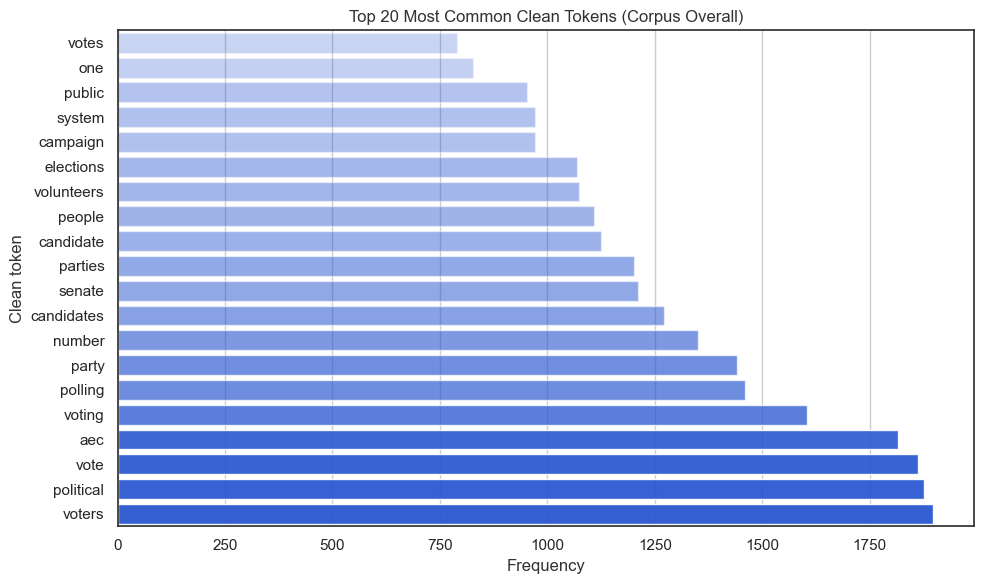

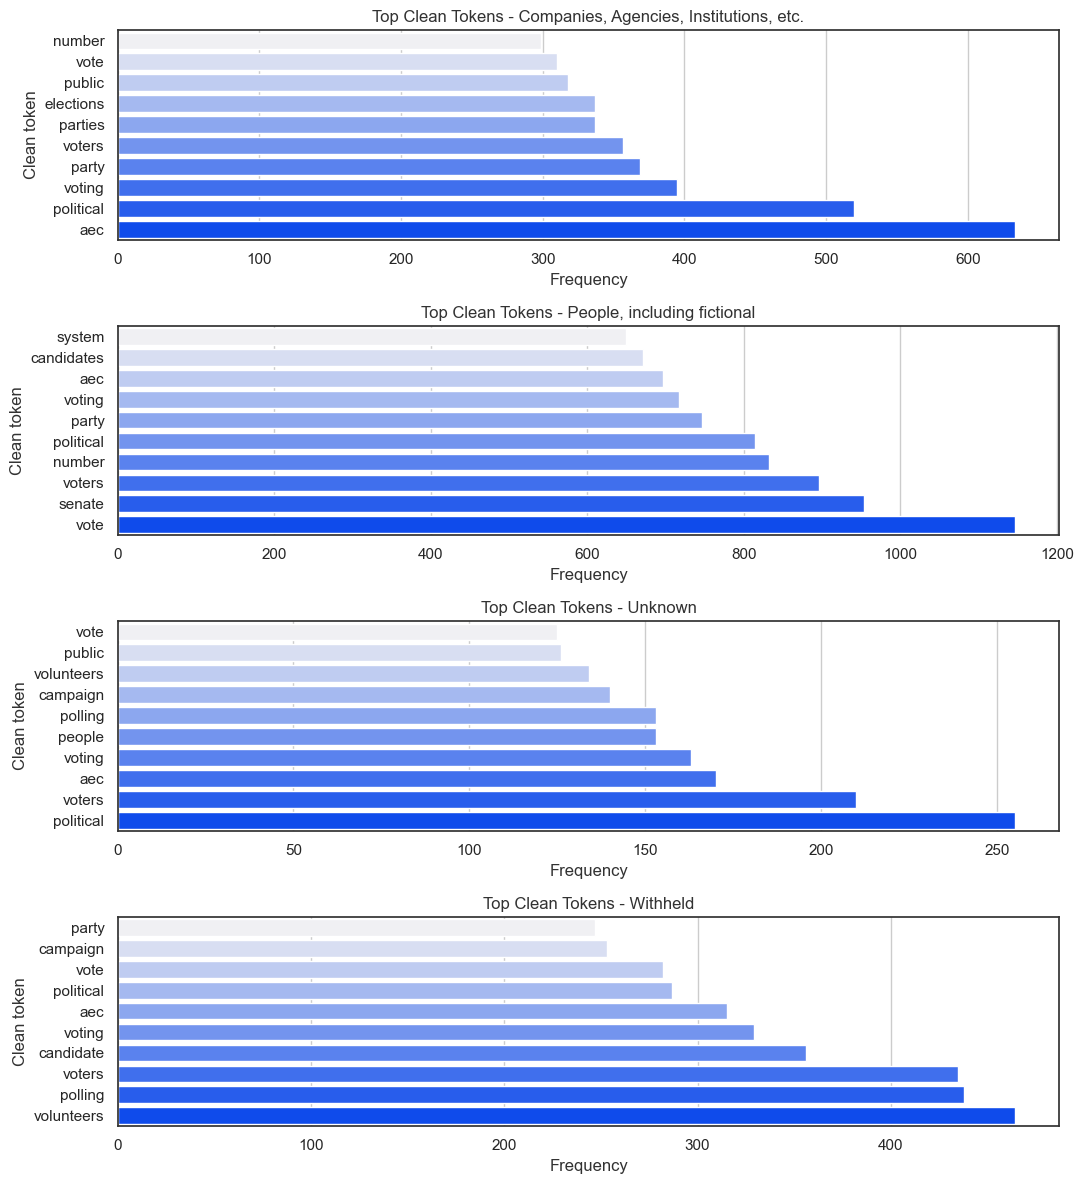

Top clean tokens by submitter type (top 10 each):


,submitter_type,word,count
0,"Companies, Agencies, Institutions, etc.",aec,633
1,"Companies, Agencies, Institutions, etc.",political,520
2,"Companies, Agencies, Institutions, etc.",voting,395
3,"Companies, Agencies, Institutions, etc.",party,369
4,"Companies, Agencies, Institutions, etc.",voters,357
5,"Companies, Agencies, Institutions, etc.",elections,337
6,"Companies, Agencies, Institutions, etc.",parties,337
7,"Companies, Agencies, Institutions, etc.",public,318
8,"Companies, Agencies, Institutions, etc.",vote,310
9,"Companies, Agencies, Institutions, etc.",number,299


In [19]:
# 4.2 Visuals: most common words (clean tokens)

overall_word_counter = Counter(all_tokens)
top_words_df = pd.DataFrame(overall_word_counter.most_common(20), columns=["word", "count"])
plot_top_words = top_words_df.sort_values("count", ascending=True)

LOGGER.info("Clean token visualization prepared: unique_clean_tokens=%d", len(overall_word_counter))

# Chart 1: overall top clean tokens
visuals.bar(
    data=plot_top_words,
    x="count",
    y="word",
    color=UTS_PALETTE["blue"],
    title="Top 20 Most Common Clean Tokens (Corpus Overall)",
    xlabel="Frequency",
    ylabel="Clean token",
    figsize=(10, 6),
)

# Top clean tokens by submitter type
rows = []
for submitter_type, group_df in corpus_df.groupby("submitter_type"):
    type_tokens = [
        token
        for tokens in group_df["clean_tokens"]
        for token in tokens
    ]
    type_counter = Counter(type_tokens)
    for word, count in type_counter.most_common(10):
        rows.append({"submitter_type": submitter_type, "word": word, "count": count})

top_words_by_type_df = pd.DataFrame(rows)

# Chart 2: top clean tokens by submitter type (faceted)
submitter_types = list(top_words_by_type_df["submitter_type"].dropna().unique())
fig, axes = plt.subplots(
    nrows=len(submitter_types),
    ncols=1,
    figsize=(11, max(3 * len(submitter_types), 6)),
    sharex=False,
)

if len(submitter_types) == 1:
    axes = [axes]

for ax, submitter_type in zip(axes, submitter_types):
    type_data = (
        top_words_by_type_df[top_words_by_type_df["submitter_type"] == submitter_type]
        .sort_values("count", ascending=True)
    )

    sns.barplot(data=type_data, x="count", y="word", color=UTS_PALETTE["blue"], ax=ax)

    gradient_colors = sns.light_palette(UTS_PALETTE["blue"], n_colors=len(type_data))
    for bar, color in zip(ax.patches, gradient_colors):
        bar.set_facecolor(color)

    ax.set_title(f"Top Clean Tokens - {submitter_type}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Clean token")

plt.tight_layout()
plt.show()

print("Top clean tokens by submitter type (top 10 each):")
top_words_by_type_df.sort_values(["submitter_type", "count"], ascending=[True, False]).head(60)


**Interpretation.** Because these charts use `clean_tokens`, the dominant terms are easier to interpret than raw-token counts and better reflect substantive inquiry themes rather than formatting noise or stopwords. The overall chart highlights the shared vocabulary that anchors the corpus, while the faceted charts show whether those priorities are consistent across submitter groups or whether some groups emphasize different concerns.

**Why this matters.** Word-frequency patterns are often the clearest bridge between raw text and later topic models. If a few cleaned terms dominate across most groups, that suggests strong common concerns in the corpus. If the vocabulary diverges by `submitter_type`, that strengthens the case for looking at group differences and latent thematic structure in more detail.

### 4.3 Corpus snapshot statistics

This cell reports compact EDA summary statistics used to frame the visual analysis.

Think of this as a checkpoint in the story: after cleaning the corpus, the notebook pauses to summarize how large, varied, and information-rich the text now looks before moving into n-grams and models.

In [20]:
# 4.3 Snapshot statistics

print("=== EDA Snapshot ===")
print(f"Documents analysed: {len(corpus_df)}")
print(f"Corpus vocabulary size (clean tokens): {vocab_size:,}")
print(f"Median document word count (raw): {corpus_df['word_count_raw'].median():.0f}")
print(f"Median lexical diversity: {corpus_df['lexical_diversity'].median():.3f}")

=== EDA Snapshot ===
Documents analysed: 299
Corpus vocabulary size (clean tokens): 20,336
Median document word count (raw): 815
Median lexical diversity: 0.668


**Interpretation.** These headline figures summarize the cleaned corpus in one place: how many submissions are being analyzed, how large the cleaned vocabulary is, how long a typical document is, and how varied the wording tends to be. Together they suggest the corpus is both sizable and diverse enough for more than one method of analysis.

**Why this matters.** Snapshot statistics help keep the later charts anchored. They remind the reader that every topic model, cluster map, and phrase chart is being built on a corpus that is not tiny, not uniform, and not dominated by a single repeated template.

### 4.4 Length comparison by submitter type

This visual compares cleaned document lengths across submitter categories to show whether the same groups remain relatively longer after preprocessing.

The main idea is to check whether differences in document size still hold once common filler language has been removed. If they do, then length differences are likely to reflect real differences in submission style rather than just formatting noise.

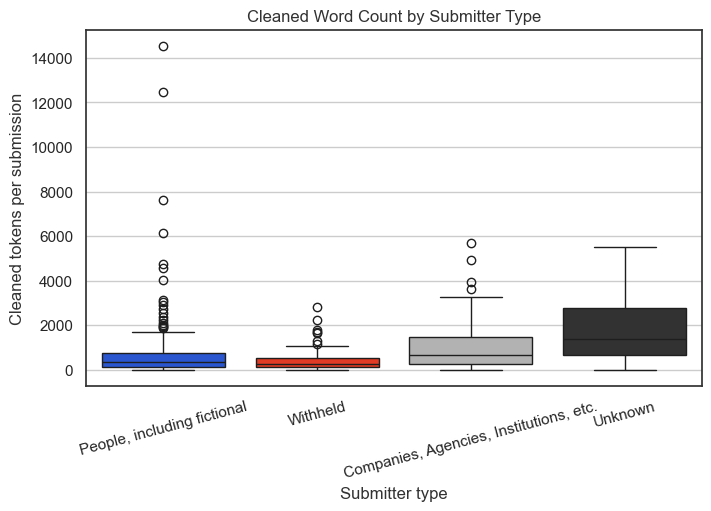

In [21]:
# 4.4 Visual: grouped comparison by submitter type (using clean tokens only)

submitter_order = corpus_df["submitter_type"].dropna().value_counts().index.tolist()
palette_cycle = [
    UTS_PALETTE["blue"],
    UTS_PALETTE["red"],
    UTS_PALETTE["mid_grey"],
    UTS_PALETTE["dark_grey"],
]
submitter_palette = {
    label: palette_cycle[idx % len(palette_cycle)]
    for idx, label in enumerate(submitter_order)
}

# Only plot cleaned word counts, since we want to focus on clean tokens
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

sns.boxplot(
    data=corpus_df,
    x="submitter_type",
    y="clean_word_count",
    order=submitter_order,
    hue="submitter_type",
    palette=submitter_palette,
    dodge=False,
    legend=False,
    ax=ax,
)
ax.set_title("Cleaned Word Count by Submitter Type")
ax.set_xlabel("Submitter type")
ax.set_ylabel("Cleaned tokens per submission")
ax.tick_params(axis="x", rotation=15)

plt.show()

**Interpretation.** The grouped comparison shows whether length differences survive the cleaning process. If the same submitter types remain relatively longer after preprocessing, then those differences are likely to reflect genuine variation in how much substantive material each group tends to provide.

**Why this matters.** This chart helps distinguish between two possibilities: one group may only look longer because of formatting and repeated boilerplate, or it may genuinely contribute more policy content. Seeing the length pattern persist after cleaning supports the second interpretation and adds context for later topic and cluster comparisons.

### 4.5 Frequency table preparation (unigrams, NPMI bigrams, and NPMI trigrams)

This cell computes unigram frequencies from the cleaned token stream and phrase frequencies from the NPMI bigram and trigram outputs so the following charts can compare raw n-grams against detected phrase units.

**What these concepts mean:**
- A **unigram** is a single token.
- A **bigram** is a two-word sequence.
- A **trigram** is a three-word sequence.
- **NPMI** (Normalized Pointwise Mutual Information) is a collocation measure that helps identify word combinations that occur together more meaningfully than chance would suggest.

This matters because raw adjacency alone can produce many common but uninformative phrases, whereas NPMI helps highlight combinations that behave more like stable concepts.

In [22]:
# 4.5 Frequency tables

raw_unigram_counts = Counter(raw_all_tokens)
clean_unigram_counts = Counter(all_tokens)
raw_bigram_counts = TextAnalytics.compute_ngram_counts(corpus_df["raw_tokens"], n=2)
raw_trigram_counts = TextAnalytics.compute_ngram_counts(corpus_df["raw_tokens"], n=3)
npmi_bigram_counts = Counter(
    token.replace("_", " ")
    for tokens in corpus_df["pmi_bigram_tokens"]
    for token in tokens
    if token.count("_") == 1
)
npmi_trigram_counts = Counter(
    token.replace("_", " ")
    for tokens in corpus_df["pmi_trigram_tokens"]
    for token in tokens
    if token.count("_") == 2
)

top_raw_unigrams = pd.DataFrame(raw_unigram_counts.most_common(20), columns=["term", "count"])
top_clean_unigrams = pd.DataFrame(clean_unigram_counts.most_common(20), columns=["term", "count"])

top_raw_bigrams = pd.DataFrame(
    [(" ".join(bg), count) for bg, count in raw_bigram_counts.most_common(15)],
    columns=["bigram", "count"],
)
top_npmi_bigrams = pd.DataFrame(
    list(npmi_bigram_counts.most_common(15)),
    columns=["bigram", "count"],
)

top_raw_trigrams = pd.DataFrame(
    [(" ".join(tg), count) for tg, count in raw_trigram_counts.most_common(15)],
    columns=["trigram", "count"],
)
top_npmi_trigrams = pd.DataFrame(
    list(npmi_trigram_counts.most_common(15)),
    columns=["trigram", "count"],
)

print("Top 10 raw unigrams:")
display(top_raw_unigrams.head(10))

print("Top 10 clean unigrams:")
display(top_clean_unigrams.head(10))

print("Top 10 raw bigrams:")
display(top_raw_bigrams.head(10))

print("Top 10 NPMI bigram phrases:")
display(top_npmi_bigrams.head(10))

print("Top 10 raw trigrams:")
display(top_raw_trigrams.head(10))

print("Top 10 NPMI trigram phrases:")
display(top_npmi_trigrams.head(10))

Top 10 raw unigrams:


,term,count
0,the,35068
1,of,17203
2,to,16497
3,and,14984
4,in,10000
5,a,9393
6,that,6236
7,for,6110
8,election,5261
9,is,4989


Top 10 clean unigrams:


,term,count
0,voters,1898
1,political,1876
2,vote,1863
3,aec,1815
4,voting,1604
5,polling,1460
6,party,1442
7,number,1351
8,candidates,1272
9,senate,1211


Top 10 raw bigrams:


...

,bigram,count
0,pre poll,383
1,w w,276
2,ballot paper,260
3,election day,259
4,political advertising,257
5,polling booth,243
6,polling booths,241
7,polling places,237
8,polling place,208
9,social media,202


Top 10 raw trigrams:


,trigram,count
0,the federal election,2496
1,inquiry into the,2253
2,into the federal,2156
3,federal election submission,2035
4,the number of,622
5,house of representatives,527
6,the house of,406
7,joint standing committee,335
8,committee on electoral,334
9,standing committee on,325


Top 10 NPMI trigram phrases:


,trigram,count
0,truth political advertising,140
1,house of representatives,126
2,australian electoral commission,93
3,the electoral act,87
4,new south wales,83
5,length parliamentary term,56
6,the liberal party,53
7,composition whole including,45
8,alp per cent,42
9,special minister state,41


### 4.6 Top unigram frequency chart

These charts visualize the most common single-word terms in separate raw-token and cleaned-token views so the effect of preprocessing is easy to compare.

A **unigram frequency chart** is one of the simplest NLP views, but it is very useful for storytelling because it shows how the vocabulary changes once cleaning decisions have been applied.

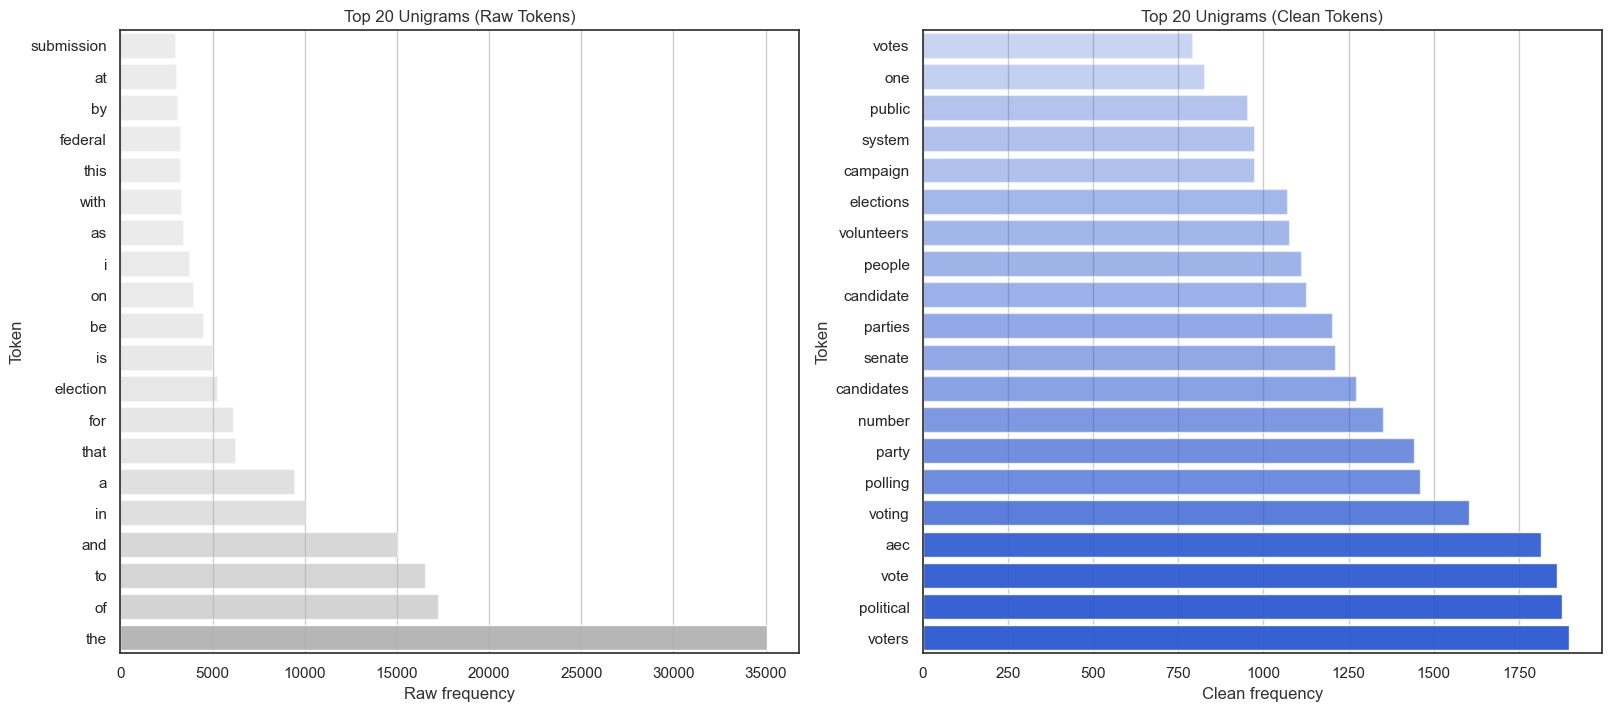

In [23]:
# 4.6 Visual: top unigrams

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7), constrained_layout=True)

visuals.bar(
    data=top_raw_unigrams.sort_values("count", ascending=True),
    x="count",
    y="term",
    color=UTS_PALETTE["mid_grey"],
    title="Top 20 Unigrams (Raw Tokens)",
    xlabel="Raw frequency",
    ylabel="Token",
    ax=axes[0],
)

visuals.bar(
    data=top_clean_unigrams.sort_values("count", ascending=True),
    x="count",
    y="term",
    color=UTS_PALETTE["blue"],
    title="Top 20 Unigrams (Clean Tokens)",
    xlabel="Clean frequency",
    ylabel="Token",
    ax=axes[1],
)

plt.show()

**Interpretation.** Showing raw and clean unigram charts separately makes the effect of preprocessing much easier to see. The raw-token view still contains more generic language, while the cleaned-token view concentrates attention on terms that are easier to connect to substantive inquiry themes.

**What the result suggests.** Terms such as `political`, `voters`, `aec`, and `vote` indicate that the corpus remains strongly centered on electoral administration, participation, and institutional process even after general context words are filtered out. That is a useful sign that the cleaning strategy is preserving topic-relevant vocabulary rather than stripping too much meaning away.

### 4.7 Bigram phrase visuals (frequency chart and network graph)

This subsection compares frequent raw bigrams with detected NPMI bigram phrases and then visualizes the phrase-based bigram structure as a network using the lemmatized phrase tokens.

The two main ideas here are **collocations** and **networks**. A collocation is a word combination that tends to appear together, while a network graph helps show how those phrase elements connect across the corpus rather than only how often they appear.

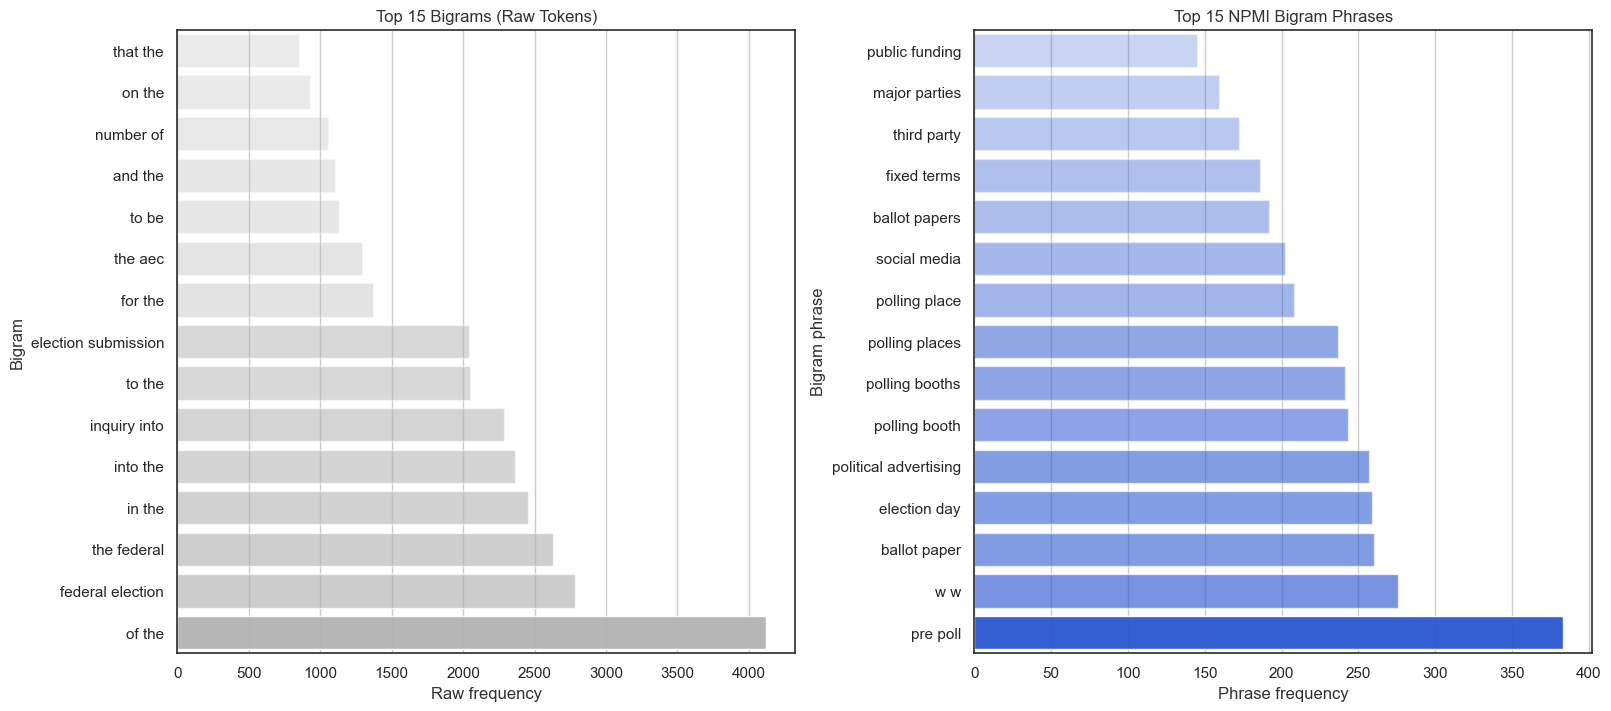

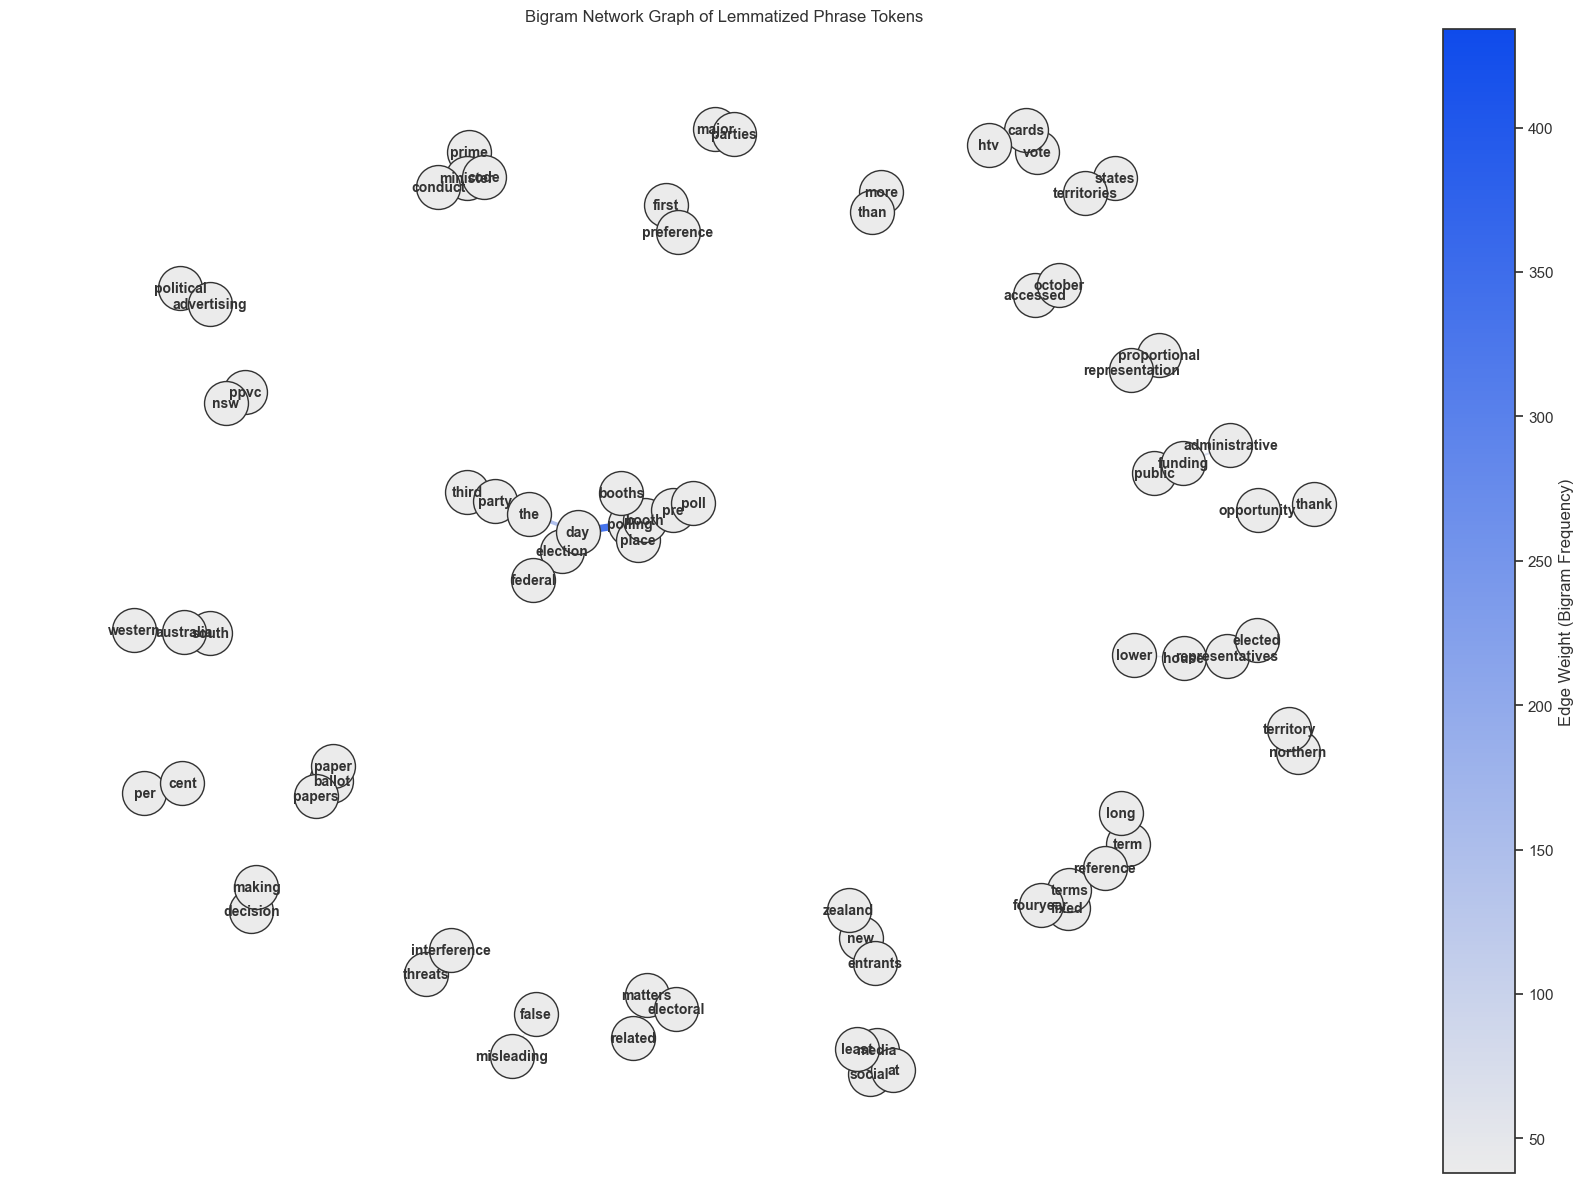

In [24]:
# 4.7 Bigram phrase visuals

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7), constrained_layout=True)

visuals.bar(
    data=top_raw_bigrams.sort_values("count", ascending=True),
    x="count",
    y="bigram",
    color=UTS_PALETTE["mid_grey"],
    title="Top 15 Bigrams (Raw Tokens)",
    xlabel="Raw frequency",
    ylabel="Bigram",
    ax=axes[0],
)

visuals.bar(
    data=top_npmi_bigrams.sort_values("count", ascending=True),
    x="count",
    y="bigram",
    color=UTS_PALETTE["blue"],
    title="Top 15 NPMI Bigram Phrases",
    xlabel="Phrase frequency",
    ylabel="Bigram phrase",
    ax=axes[1],
)

plt.show()

lemmatized_phrase_tokens = [
    token
    for tokens in corpus_df["lemmatized_tokens"]
    if isinstance(tokens, list)
    for token in tokens
    if isinstance(token, str) and token.count("_") == 1
]

visuals.bigram_network(
    tokens=lemmatized_phrase_tokens,
    title="Bigram Network Graph of Lemmatized Phrase Tokens",
    n=50,
    figsize=(16, 12),
)

**Interpretation.** Bigrams add more context than single terms, and the NPMI phrase model highlights word pairs that cohere strongly enough to be treated as phrase-like units. Comparing raw bigrams with detected NPMI bigram phrases shows the difference between simple adjacency and more meaningful collocations.

**What the result adds to the story.** When terms begin to form stable pairs, the discussion becomes more interpretable because the corpus is no longer just about isolated words. The network graph then makes those phrase relationships visible as a structure, showing which ideas are repeatedly connected across the submissions rather than simply frequent in isolation.

### 4.8 Top three-gram frequency chart (using NPMI phrase output)

These charts compare frequent raw trigrams with the NPMI trigram phrases detected from the phrase-modeled token stream so longer recurring expressions are easier to interpret.

Trigrams are especially helpful when the corpus contains recurring policy expressions that need more than two words to become meaningful, for example when a phrase names an institution, procedure, or public issue more precisely than a unigram or bigram can.

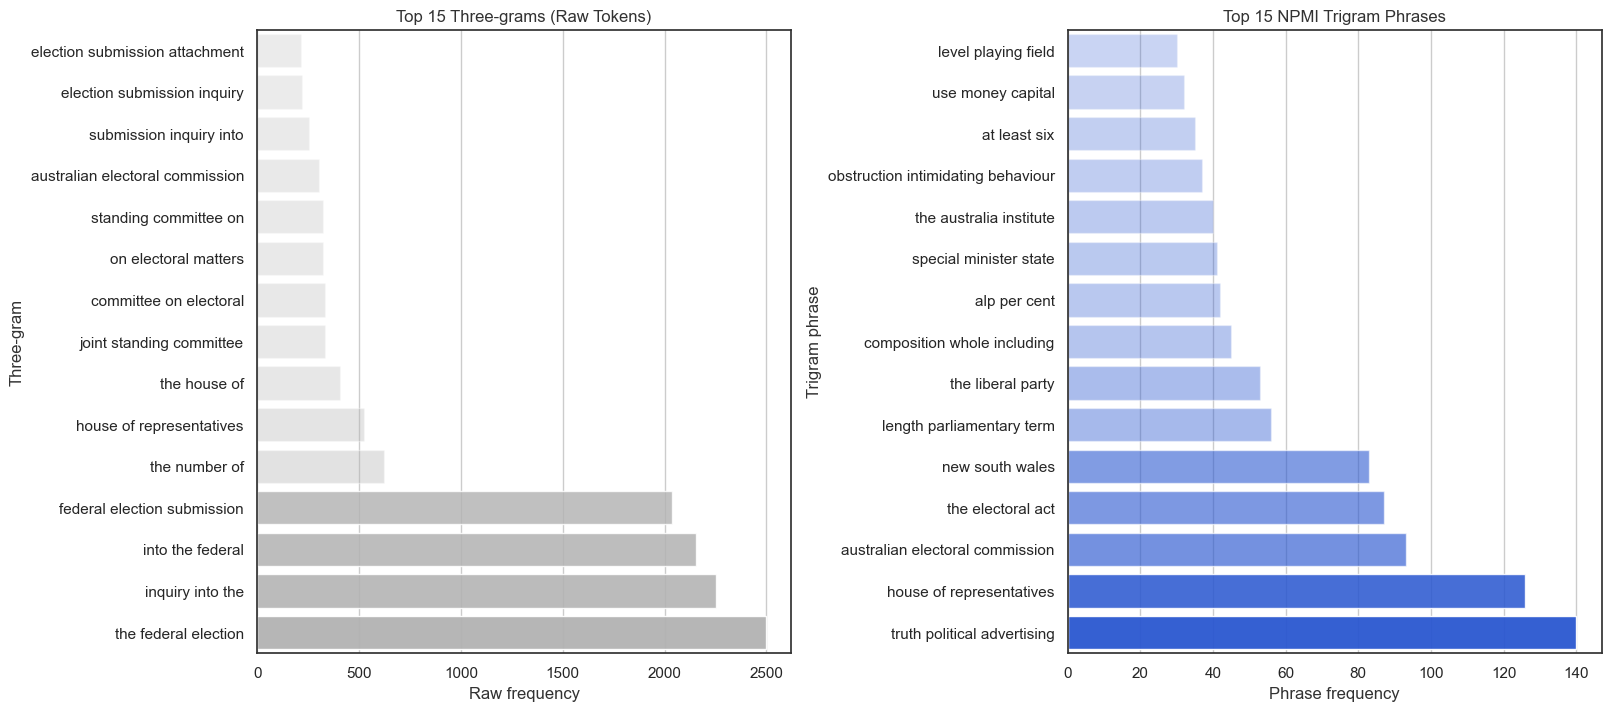

In [25]:
# 4.8 Visual: top three-grams

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7), constrained_layout=True)

visuals.bar(
    data=top_raw_trigrams.sort_values("count", ascending=True),
    x="count",
    y="trigram",
    color=UTS_PALETTE["mid_grey"],
    title="Top 15 Three-grams (Raw Tokens)",
    xlabel="Raw frequency",
    ylabel="Three-gram",
    ax=axes[0],
)

visuals.bar(
    data=top_npmi_trigrams.sort_values("count", ascending=True),
    x="count",
    y="trigram",
    color=UTS_PALETTE["blue"],
    title="Top 15 NPMI Trigram Phrases",
    xlabel="Phrase frequency",
    ylabel="Trigram phrase",
    ax=axes[1],
)

plt.show()

**Interpretation.** NPMI trigrams are more selective than raw three-grams because they emphasize phrase-like expressions rather than any frequent three-word sequence. Comparing raw trigrams with detected NPMI trigram phrases therefore helps separate recurring concepts from incidental word order.

**Why this matters.** Longer phrase units often capture policy language more faithfully than single tokens do. When stable three-word expressions appear repeatedly, they provide a stronger bridge into downstream topic interpretation because they preserve more context about institutions, procedures, and issue framing.

### 4.9 Initial preprocessing interpretation

At this point in the notebook, the corpus contains **299 submissions** with text successfully extracted from all files. Document lengths remain highly variable after preprocessing, with a median raw length of roughly **815 words**, and organisation submissions generally appearing much longer than individual and withheld-name submissions.

The cleaned corpus vocabulary is broad (about **16.7k unique tokens**) and the median lexical diversity is around **0.66**, which suggests that the submissions are not repeating the exact same language even when they discuss related issues. High-frequency terms and phrases such as *political*, *voters*, *AEC*, *house representatives*, and *political advertising* indicate that institutional process, electoral administration, and campaign regulation are already emerging as dominant themes.

**Story so far.** The corpus is large enough, varied enough, and linguistically rich enough to justify moving from descriptive analysis into modeling. The next section therefore shifts from asking "what words are common?" to asking "what broader themes and document groupings can we uncover?"

### 4.10 Word cloud of preprocessed corpus

This visual summary highlights the relative prominence of terms in the fully preprocessed corpus.

A **word cloud** is a communication-oriented visualization: larger words appear more prominent, but the chart is approximate rather than exact. It works well as a storytelling device at the end of the preprocessing section because it gives a quick visual impression of the vocabulary before the notebook moves into formal modeling.

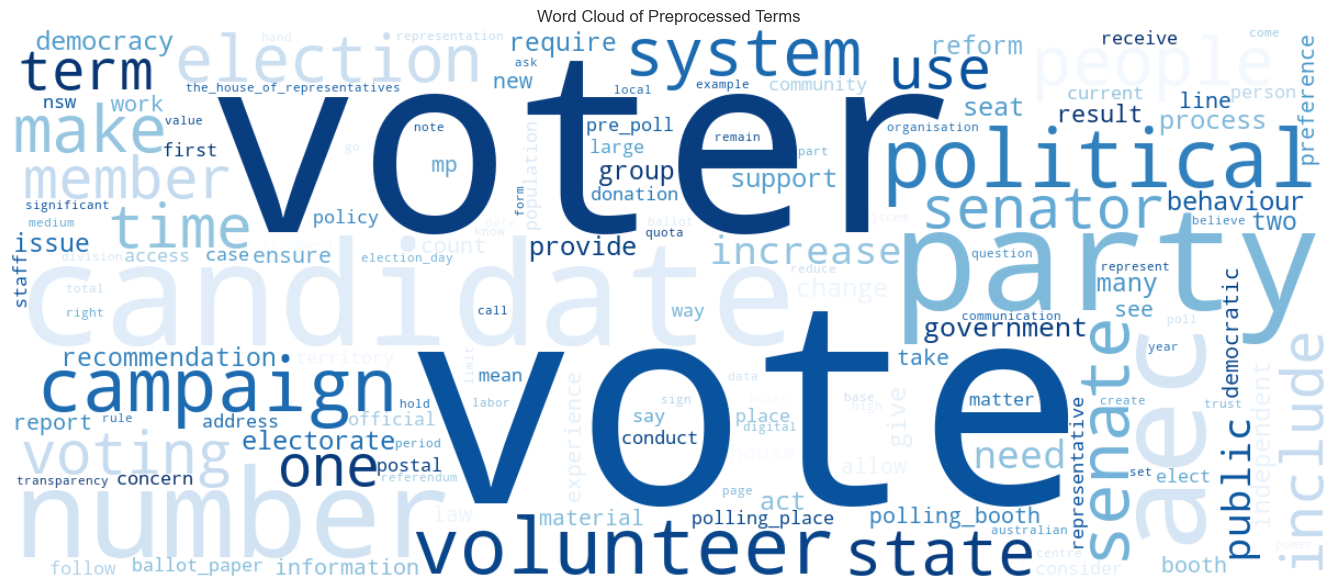

In [26]:
# 4.10 Word cloud

wordcloud_text = " ".join(corpus_df["preprocessed_text"].fillna(""))

visuals.wordcloud(
    text=wordcloud_text,
    title="Word Cloud of Preprocessed Terms",
    width=1200,
    height=500,
    max_words=150,
    colormap="Blues",
    background_color=UTS_PALETTE["white"],
    figsize=(14, 6),
)

**Interpretation.** Unlike the ranked bar charts, the word cloud gives a quick holistic sense of vocabulary prominence and thematic concentration across the preprocessed corpus. It works well as a visual summary because the reader can immediately see which ideas occupy the largest share of the lexical space.

**Why this matters.** The word cloud is strongest as a communication tool rather than a measurement tool. It helps close the preprocessing section with an intuitive visual impression of the corpus, while the more precise interpretation still comes from the ranked frequency tables and bar charts.

<a id="topic-modeling"></a>

## 5. Advanced Methods (Topic Modeling and Clustering)

This section extends the descriptive analysis with topic modeling and unsupervised clustering so the corpus can be compared through latent themes, document groupings, and broader patterns of policy discussion.

**Why this section is needed.** Frequency charts are useful, but they mostly tell us which words and phrases are common. They do not automatically tell us how those terms combine into broader themes or which submissions are similar to one another overall. That is where topic modeling and clustering become helpful.

**Core concepts introduced here:**
- **LDA topic modeling** estimates hidden themes by finding groups of words that tend to appear together across documents.
- **TF-IDF** gives more weight to terms that help distinguish one document from another.
- **Clustering** groups documents that are similar in vocabulary or semantic profile.
- **Dimensionality reduction** simplifies high-dimensional text features so they can be modeled and visualized more clearly.
- **UMAP** projects complex document relationships into two dimensions for an interpretable map-like view.

### 5.1 Topic modeling with LDA

This cell evaluates candidate topic counts with a coherence score, selects the strongest LDA solution, and summarizes each topic using high-probability terms.

**What is LDA?** Latent Dirichlet Allocation (LDA) is a topic-modeling method that treats each document as a mixture of topics and each topic as a mixture of words. It does not assign one fixed label to a document by itself; instead, it estimates probabilities that indicate how strongly each topic appears in each submission.

**What is coherence?** Topic coherence is a quality check that estimates whether the top words in a topic make semantic sense together. In this notebook, coherence is used to compare several candidate topic counts so the final model is selected on an interpretable basis rather than by guesswork.

2026-03-09 15:53:58,016 | INFO | adding document #0 to Dictionary<0 unique tokens: []>
2026-03-09 15:53:58,144 | INFO | built Dictionary<18463 unique tokens: ['accept', 'act', 'additional', 'anomalous', 'apply']...> from 299 documents (total 235649 corpus positions)
2026-03-09 15:53:58,145 | INFO | Dictionary lifecycle event {'msg': "built Dictionary<18463 unique tokens: ['accept', 'act', 'additional', 'anomalous', 'apply']...> from 299 documents (total 235649 corpus positions)", 'datetime': '2026-03-09T15:53:58.145501', 'gensim': '4.4.0', 'python': '3.12.8 (v3.12.8:2dc476bcb91, Dec  3 2024, 14:43:19) [Clang 13.0.0 (clang-1300.0.29.30)]', 'platform': 'macOS-26.1-arm64-arm-64bit', 'event': 'created'}
2026-03-09 15:53:58,147 | INFO | using ParallelWordOccurrenceAccumulator<processes=7, batch_size=64> to estimate probabilities from sliding windows
2026-03-09 15:54:05,061 | INFO | 1 batches submitted to accumulate stats from 64 documents (41418 virtual)
2026-03-09 15:54:05,068 | INFO | 2 b

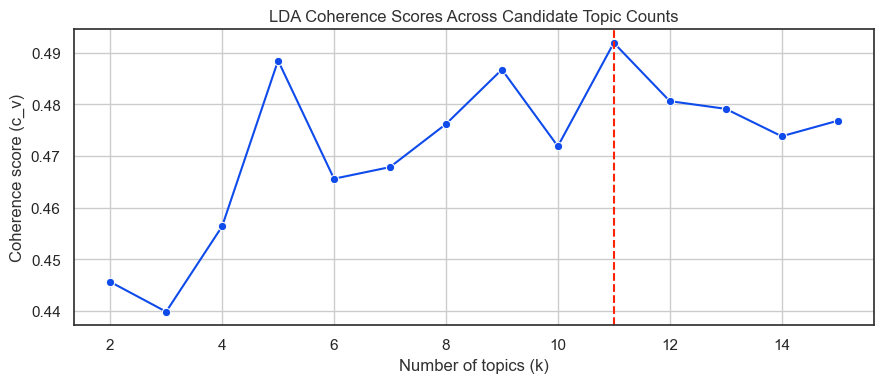

,k,coherence_score
0,2,0.445617
1,3,0.439833
2,4,0.456361
3,5,0.488453
4,6,0.465579
5,7,0.467826
6,8,0.476158
7,9,0.486712
8,10,0.471857
9,11,0.491879


,topic,top_terms
0,Topic 1,"senator, senate, term, state, number, house, s..."
1,Topic 2,"vote, system, senate, number, voter, line, aec..."
2,Topic 3,"volunteer, voter, candidate, campaign, party, ..."
3,Topic 4,"party, political, democracy, people, candidate..."
4,Topic 5,"vote, candidate, preference, number, voter, sy..."
5,Topic 6,"vote, party, take, say, time, people, go, one,..."
6,Topic 7,"political, digital, include, campaign, public,..."
7,Topic 8,"charity, term, support, public, member, mp, in..."
8,Topic 9,"vote, nsw, ppvc, voter, vic, state, one, senat..."
9,Topic 10,"vote, aec, process, ballot, election, voting, ..."


In [27]:
# 5.1 LDA topic modeling

vectorizer = CountVectorizer(max_df=0.9, min_df=5)
dtm = vectorizer.fit_transform(corpus_df["preprocessed_text"])
feature_names = vectorizer.get_feature_names_out()
lemmatized_docs = corpus_df["lemmatized_tokens"].tolist()

topic_candidates = list(range(2, 16))
coherence_rows = []
lda_candidates = {}

for k in topic_candidates:
    candidate_model = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method="batch",
        max_iter=20,
    )
    candidate_model.fit(dtm)
    lda_candidates[k] = candidate_model
    coherence_rows.append(
        {
            "k": k,
            "coherence_score": TextAnalytics.get_coherence_score(lemmatized_docs, candidate_model, feature_names),
        }
    )

coherence_df = pd.DataFrame(coherence_rows)
n_topics = int(
    coherence_df.sort_values(["coherence_score", "k"], ascending=[False, True]).iloc[0]["k"]
)
lda_model = lda_candidates[n_topics]
topic_distributions = lda_model.transform(dtm)
topic_terms_df = TextAnalytics.extract_top_terms_per_topic(lda_model, feature_names, top_n=10)

LOGGER.info(
    "LDA fitted: topics=%d, vocabulary=%d, coherence=%.4f",
    n_topics,
    len(feature_names),
    coherence_df.loc[coherence_df["k"] == n_topics, "coherence_score"].iloc[0],
)

plt.figure(figsize=(9, 4))
sns.lineplot(data=coherence_df, x="k", y="coherence_score", marker="o", color=UTS_PALETTE["blue"])
plt.axvline(n_topics, color=UTS_PALETTE["red"], linestyle="--", linewidth=1.5)
plt.title("LDA Coherence Scores Across Candidate Topic Counts")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence score (c_v)")
plt.tight_layout()
plt.show()

display(coherence_df)
topic_terms_df

**Interpretation.** The coherence curve compares several candidate topic counts and marks the selected solution with a vertical line. In this run, the chosen model is the one with the strongest coherence score, meaning its top words form the most semantically consistent combination among the tested options.

**Why this matters.** A topic model is only useful if its topics make human sense. Using coherence as a selection rule makes the LDA result easier to justify and easier to explain to a non-technical reader.

### 5.2 Topic prevalence across submissions

This cell assigns each submission to its dominant topic and visualizes topic prevalence to show which themes are most represented in the corpus.

The key concept here is **dominant topic**: although an LDA document is a mixture of topics, it is often useful for storytelling to assign each document to the topic with the highest probability and then count how many documents are mostly associated with each theme.

2026-03-09 15:55:36,828 | INFO | Topic prevalence computed for 299 submissions


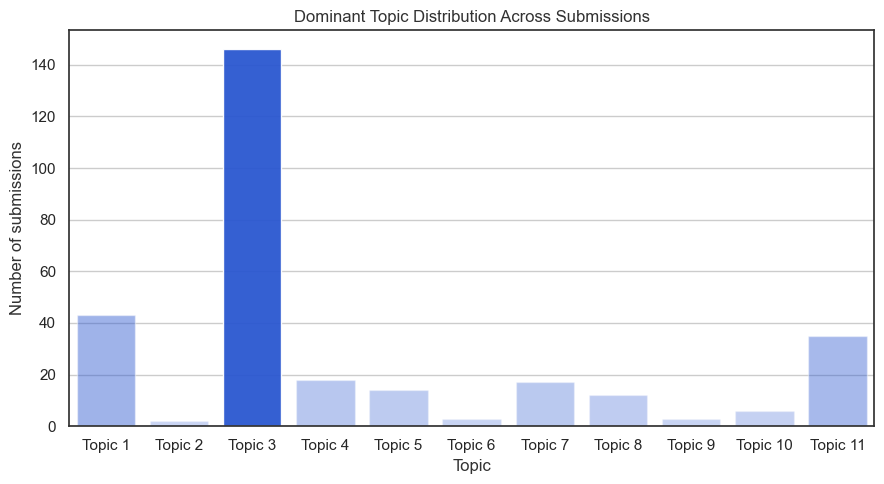

,topic,count
0,Topic 1,43
1,Topic 2,2
2,Topic 3,146
3,Topic 4,18
4,Topic 5,14
5,Topic 6,3
6,Topic 7,17
7,Topic 8,12
8,Topic 9,3
9,Topic 10,6


In [28]:
# 5.2 Topic prevalence

corpus_df["dominant_topic"] = topic_distributions.argmax(axis=1) + 1
topic_counts = (
    corpus_df["dominant_topic"]
    .value_counts()
    .sort_index()
    .rename_axis("topic")
    .reset_index(name="count")
)

topic_counts["topic"] = topic_counts["topic"].astype(str).radd("Topic ")
LOGGER.info("Topic prevalence computed for %d submissions", len(corpus_df))

visuals.bar(
    data=topic_counts,
    x="topic",
    y="count",
    color=UTS_PALETTE["blue"],
    title="Dominant Topic Distribution Across Submissions",
    xlabel="Topic",
    ylabel="Number of submissions",
    figsize=(9, 5),
)

topic_counts

**Interpretation.** This chart shows whether the corpus is dominated by a few broad themes or distributed across several topic groupings. If one or two topics clearly dominate, then much of the inquiry discussion is concentrated around a limited set of concerns. If the bars are more evenly spread, the corpus covers a broader policy agenda.

**Why this matters.** Topic prevalence translates the abstract LDA output into a much simpler policy story: which themes are most common across the submissions, and whether the corpus is tightly focused or thematically diverse.

### 5.3 Hierarchical clustering of submissions

This cell builds a TF-IDF representation of the preprocessed submissions, reduces dimensionality for stable distance calculations, and uses hierarchical clustering to visualize how documents merge into broader thematic groupings.

**What these concepts mean:**
- **TF-IDF** (Term Frequency-Inverse Document Frequency) highlights words that are frequent in a document but not equally common in every document.
- **SVD** reduces the number of dimensions while preserving the main structure of the feature space.
- **Hierarchical clustering** groups documents step by step, creating a tree-like structure that shows which items merge earlier or later based on similarity.

This is helpful when the goal is not just to force documents into a fixed number of groups, but also to see the broader structure of similarity across the corpus.

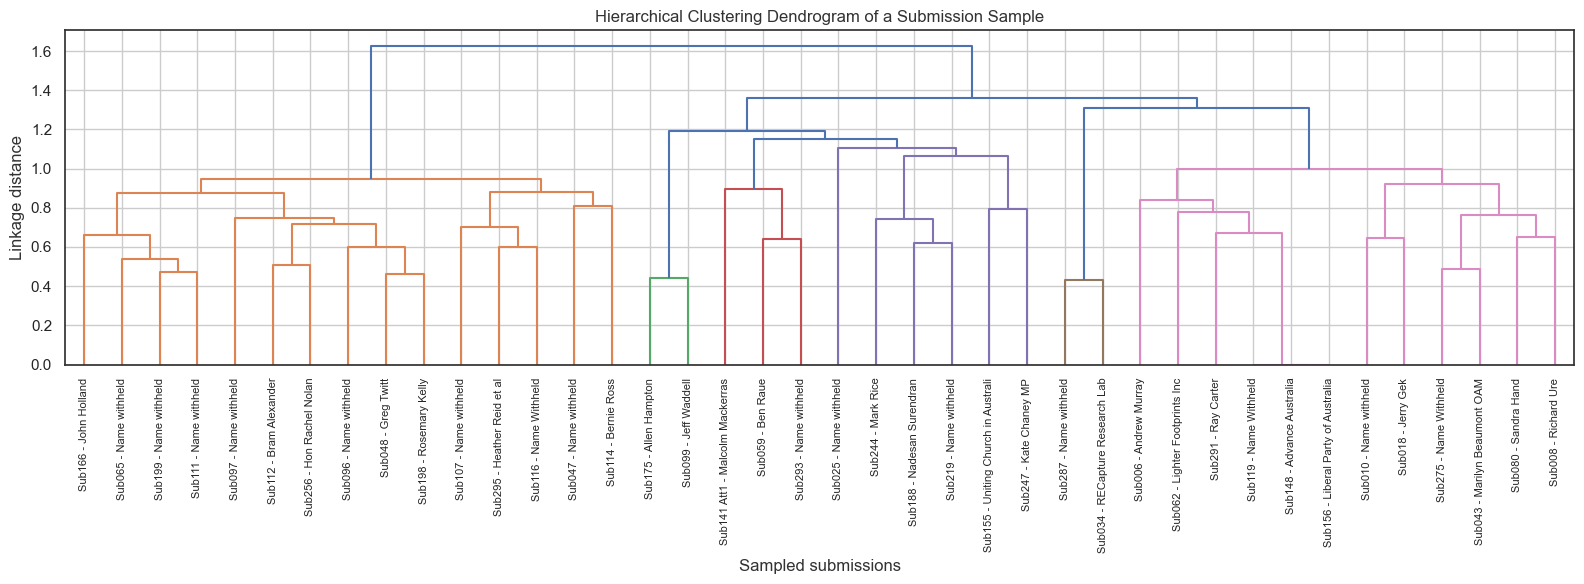

2026-03-09 15:55:37,340 | INFO | Hierarchical clustering complete: docs=299, features=5771, clusters=4


,cluster,count
0,Cluster 1,97
1,Cluster 2,131
2,Cluster 3,30
3,Cluster 4,41


,cluster,top_terms
0,Cluster 1,"aec, voter, vote, party, political, candidate,..."
1,Cluster 2,"candidate, volunteer, vote, voter, booth, peop..."
2,Cluster 3,"senate, senator, term, number, vote, elect, st..."
3,Cluster 4,"volunteer, voter, campaign, candidate, behavio..."


In [29]:
# 5.3 Hierarchical clustering

tfidf_vectorizer = TfidfVectorizer(max_df=0.9, min_df=5, ngram_range=(1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_df["preprocessed_text"])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

n_svd_components = max(2, min(50, tfidf_matrix.shape[0] - 1, tfidf_matrix.shape[1] - 1))
svd_model = TruncatedSVD(n_components=n_svd_components, random_state=42)
reduced_features = svd_model.fit_transform(tfidf_matrix)

hierarchical_labels = AgglomerativeClustering(n_clusters=4, linkage="ward").fit_predict(reduced_features)
corpus_df["hierarchical_cluster"] = hierarchical_labels + 1

sample_indices = corpus_df.sample(n=min(40, len(corpus_df)), random_state=42).index
sample_features = reduced_features[sample_indices]
sample_labels = [Path(name).stem[:35] for name in corpus_df.loc[sample_indices, "file_name"]]
linkage_matrix = linkage(sample_features, method="ward")

plt.figure(figsize=(16, 6))
dendrogram(linkage_matrix, labels=sample_labels, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram of a Submission Sample")
plt.xlabel("Sampled submissions")
plt.ylabel("Linkage distance")
plt.tight_layout()
plt.show()

hierarchical_counts = (
    corpus_df["hierarchical_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)
hierarchical_counts["cluster"] = hierarchical_counts["cluster"].astype(str).radd("Cluster ")

hierarchical_top_terms_df = TextAnalytics.extract_top_terms_per_cluster(
    tfidf_matrix,
    hierarchical_labels,
    tfidf_feature_names,
    top_n=10,
)
LOGGER.info(
    "Hierarchical clustering complete: docs=%d, features=%d, clusters=%d",
    len(corpus_df),
    len(tfidf_feature_names),
    corpus_df["hierarchical_cluster"].nunique(),
)

display(hierarchical_counts)
display(hierarchical_top_terms_df)

**Interpretation.** The dendrogram shows which submissions remain close together as clusters are merged, while the cluster summary table highlights the vocabulary that defines each branch. Tight groupings suggest repeated framings or closely related concerns across submitters, whereas longer branch distances indicate submissions that are more distinctive in emphasis or terminology.

**Why this matters.** Hierarchical clustering adds structure to the story by showing not just that documents can be grouped, but how those groupings are nested. It is therefore useful for seeing whether the corpus contains a few broad families of submissions with sub-patterns inside them.

### 5.4 K-means cluster selection

This cell evaluates several candidate values of `k` on an SVD-reduced TF-IDF representation using the elbow method and silhouette score, then selects the final k-means solution from the strongest reduced-space profile.

**What these concepts mean:**
- The **elbow method** looks for a point where adding more clusters stops giving large improvements.
- The **silhouette score** measures how well separated the clusters are, with higher values usually indicating cleaner group boundaries.

This section matters because k-means requires the number of clusters to be chosen in advance, so the notebook tests several options instead of selecting `k` arbitrarily.

2026-03-09 15:55:37,504 | INFO | K-means evaluation complete on SVD-reduced features: selected best_k=5, svd_components=50


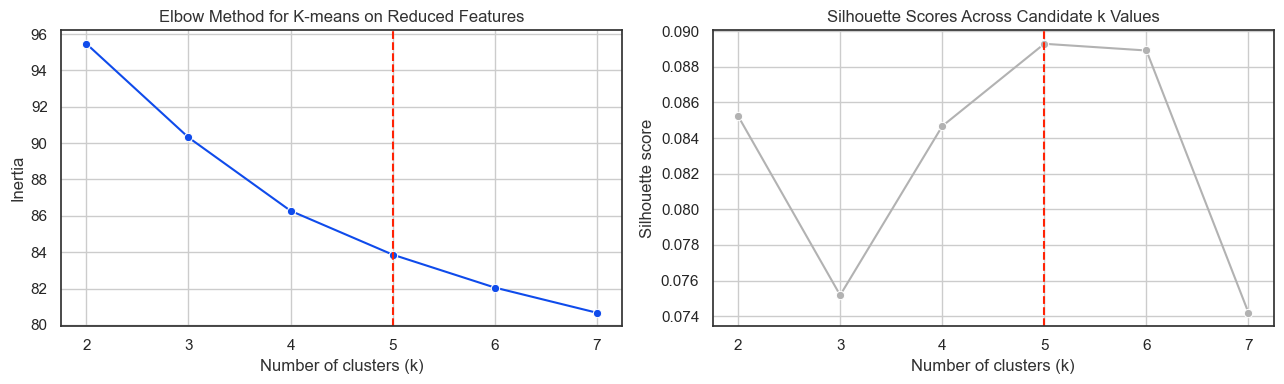

,k,inertia,silhouette_score
0,2,95.468523,0.085235
1,3,90.313699,0.075177
2,4,86.277165,0.084667
3,5,83.865691,0.089290
4,6,82.053578,0.088913
5,7,80.667786,0.074192


In [30]:
# 5.4 K-means cluster selection

kmeans_feature_matrix = reduced_features
k_candidates = list(range(2, 8))
cluster_eval_rows = []

for k in k_candidates:
    candidate_model = KMeans(n_clusters=k, random_state=42, n_init=20)
    candidate_labels = candidate_model.fit_predict(kmeans_feature_matrix)
    cluster_eval_rows.append(
        {
            "k": k,
            "inertia": candidate_model.inertia_,
            "silhouette_score": silhouette_score(kmeans_feature_matrix, candidate_labels),
        }
    )

cluster_eval_df = pd.DataFrame(cluster_eval_rows)
best_k = int(cluster_eval_df.loc[cluster_eval_df["silhouette_score"].idxmax(), "k"])
LOGGER.info(
    "K-means evaluation complete on SVD-reduced features: selected best_k=%d, svd_components=%d",
    best_k,
    n_svd_components,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(data=cluster_eval_df, x="k", y="inertia", marker="o", color=UTS_PALETTE["blue"], ax=axes[0])
axes[0].axvline(best_k, color=UTS_PALETTE["red"], linestyle="--", linewidth=1.5)
axes[0].set_title("Elbow Method for K-means on Reduced Features")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

sns.lineplot(data=cluster_eval_df, x="k", y="silhouette_score", marker="o", color=UTS_PALETTE["mid_grey"], ax=axes[1])
axes[1].axvline(best_k, color=UTS_PALETTE["red"], linestyle="--", linewidth=1.5)
axes[1].set_title("Silhouette Scores Across Candidate k Values")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

cluster_eval_df

**Interpretation.** The elbow and silhouette plots are used together. Inertia drops as `k` increases, so by itself it rarely tells us exactly where to stop. The silhouette score is more directly useful because it reflects how well separated the clusters are, and the selected `best_k` marks the strongest separation found in this run.

**Why this matters.** Choosing `k` this way makes the final clustering step more defensible. The number of clusters is informed by the structure of the corpus rather than being selected arbitrarily for visual convenience.

### 5.5 K-means cluster interpretation

This cell fits the final k-means model on the reduced feature space, builds a UMAP-style semantic cluster map with keyword callouts, and summarizes each cluster with its size, representative keywords, and example submission filenames.

Here the notebook shifts from model fitting to interpretation. **K-means** assigns each document to one cluster, while **UMAP** creates a two-dimensional projection so that similar submissions tend to appear closer together on the chart. The keyword callouts are then used as a storytelling bridge between the abstract clusters and the language that defines them.

/Users/juansebastianvargastorres/Desktop/UTS_subjects/Semester_2/NLP/nlp-parliamentary-inquiry-text-mining/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


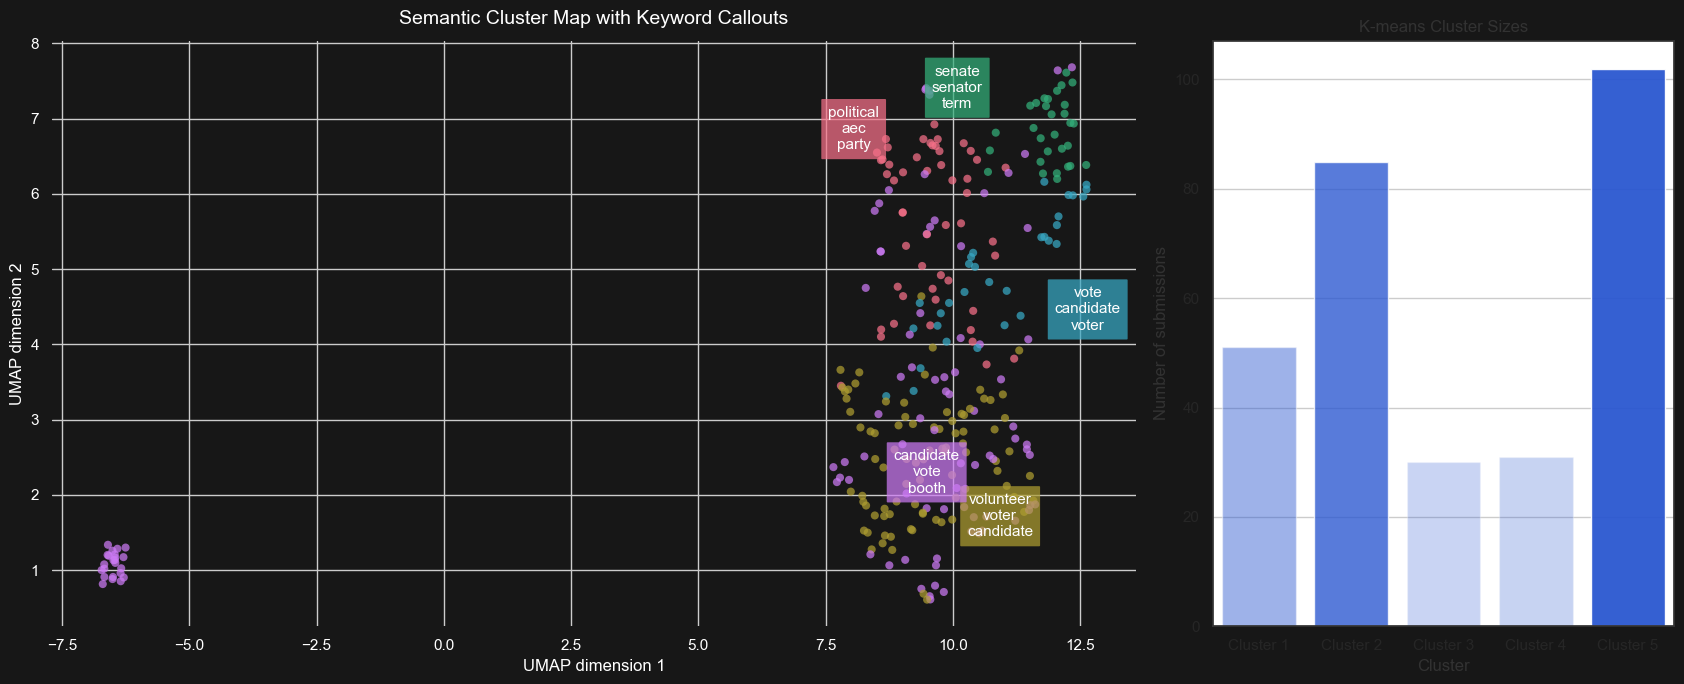

2026-03-09 15:55:42,796 | INFO | Final K-means model fitted on reduced features and visualized with UMAP: clusters=5


,cluster,top_terms
0,Cluster 1,"political, aec, party, voter, candidate, campa..."
1,Cluster 2,"volunteer, voter, candidate, campaign, aec, vo..."
2,Cluster 3,"senate, senator, term, number, state, increase..."
3,Cluster 4,"vote, candidate, voter, voting, system, prefer..."
4,Cluster 5,"candidate, vote, booth, church, member, party,..."


,file_name,kmeans_cluster
0,Sub002 - Dr Sheppard.pdf,1
1,Sub003 - Grattan Institute.pdf,1
2,Sub004 - Australian Electoral Commission.pdf,1
3,Sub007 - Genevieve Grant.pdf,2
4,Sub020 - Name withheld.pdf,2
5,Sub026 - Name withheld.pdf,2
6,Sub001 - Bob McMullan.pdf,3
7,Sub019 - Name withheld.pdf,3
8,Sub051 - Travis Jordan.pdf,3
9,Sub013 - Lex Stewart.pdf,4


In [31]:
# 5.5 Final K-means clustering

kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_labels = kmeans_model.fit_predict(reduced_features)
corpus_df["kmeans_cluster"] = kmeans_labels + 1

kmeans_counts = (
    corpus_df["kmeans_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)
kmeans_counts["cluster"] = kmeans_counts["cluster"].astype(str).radd("Cluster ")

kmeans_top_terms_df = TextAnalytics.extract_top_terms_per_cluster(
    tfidf_matrix,
    kmeans_labels,
    tfidf_feature_names,
    top_n=10,
)

kmeans_examples_df = (
    corpus_df[["file_name", "kmeans_cluster"]]
    .sort_values(["kmeans_cluster", "file_name"])
    .groupby("kmeans_cluster", group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

umap_model = umap.UMAP(
    n_neighbors=min(15, max(5, len(corpus_df) - 1)),
    min_dist=0.15,
    metric="cosine",
    n_components=2,
    random_state=42,
)
umap_projection = umap_model.fit_transform(reduced_features)
kmeans_plot_df = pd.DataFrame(umap_projection, columns=["component_1", "component_2"])
kmeans_plot_df["cluster_id"] = corpus_df["kmeans_cluster"]
kmeans_plot_df["cluster"] = corpus_df["kmeans_cluster"].astype(str).radd("Cluster ")

cluster_palette = {
    cluster_id: color
    for cluster_id, color in zip(sorted(kmeans_plot_df["cluster_id"].unique()), sns.color_palette("husl", n_colors=best_k))
}

cluster_label_positions = (
    kmeans_plot_df
    .groupby(["cluster_id", "cluster"], as_index=False)[["component_1", "component_2"]]
    .median()
)

x_range = kmeans_plot_df["component_1"].max() - kmeans_plot_df["component_1"].min()
y_range = kmeans_plot_df["component_2"].max() - kmeans_plot_df["component_2"].min()
x_offset_cycle = [-0.08, 0.08, -0.1, 0.1, 0.0, 0.12, -0.12]
y_offset_cycle = [0.12, -0.12, 0.08, -0.08, 0.0, 0.15, -0.15]

fig, axes = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={"width_ratios": [2.35, 1]})
fig.patch.set_facecolor("#171717")
axes[0].set_facecolor("#171717")
axes[1].set_facecolor(UTS_PALETTE["white"])

sns.scatterplot(
    data=kmeans_plot_df,
    x="component_1",
    y="component_2",
    hue="cluster_id",
    palette=cluster_palette,
    s=34,
    alpha=0.72,
    linewidth=0,
    ax=axes[0],
    legend=False,
)

for idx, row in cluster_label_positions.reset_index(drop=True).iterrows():
    label_terms = (
        kmeans_top_terms_df.loc[
            kmeans_top_terms_df["cluster"] == row["cluster"],
            "top_terms",
        ]
        .iloc[0]
        .split(", ")[:3]
    )
    label_text = "\n".join(label_terms)
    axes[0].text(
        row["component_1"] + (x_range * x_offset_cycle[idx % len(x_offset_cycle)]),
        row["component_2"] + (y_range * y_offset_cycle[idx % len(y_offset_cycle)]),
        label_text,
        ha="center",
        va="center",
        fontsize=11,
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.45,rounding_size=0.06",
            facecolor=cluster_palette[row["cluster_id"]],
            edgecolor="none",
            alpha=0.72,
        ),
        zorder=5,
    )

axes[0].set_title("Semantic Cluster Map with Keyword Callouts", color="white", fontsize=14, pad=12)
axes[0].set_xlabel("UMAP dimension 1", color="white")
axes[0].set_ylabel("UMAP dimension 2", color="white")
axes[0].tick_params(colors="white")
for spine in axes[0].spines.values():
    spine.set_visible(False)

visuals.bar(
    data=kmeans_counts,
    x="cluster",
    y="count",
    color=UTS_PALETTE["blue"],
    title="K-means Cluster Sizes",
    xlabel="Cluster",
    ylabel="Number of submissions",
    figsize=(7, 5),
    ax=axes[1],
)

plt.tight_layout()
plt.show()

LOGGER.info("Final K-means model fitted on reduced features and visualized with UMAP: clusters=%d", best_k)
display(kmeans_top_terms_df)
display(kmeans_examples_df)

**Interpretation.** The final visualization uses a UMAP projection of the reduced document space, which produces a more intuitive semantic map when documents form overlapping but still separable thematic neighborhoods. The colored keyword callouts make each cluster easier to interpret at a glance, while the supporting size chart, top-term table, and example filenames keep the visual grounded in the underlying submission corpus.

**Why this matters.** This is the most synthetic view in the notebook: it combines similarity structure, cluster assignment, and representative vocabulary into a single story about how the submissions are organized. Instead of asking only which words are common, the notebook can now show which submissions appear to belong together and what language gives each group its identity.

<a id="conclusion"></a>

## 6. Conclusion

Summarize your most important findings, directly answer the inquiry-focused questions, and briefly state:
- practical implications,
- limitations of the analysis,
- and recommended next steps for future work.

<a id="references"></a>

## 7. References

List all references used in this report (datasets, official sources, libraries, and academic/technical references), using one consistent citation style.